In [1]:
# Notebook data preparation ALPA-Net: universal labels, territory vectors, lead priors, patient-wise datasets.
import ast
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wfdb
from IPython.display import display
from scipy.signal import butter, filtfilt
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
print('Main target is multi-label. Use BCEWithLogitsLoss for main_label_vector, not CrossEntropyLoss.')

Main target is multi-label. Use BCEWithLogitsLoss for main_label_vector, not CrossEntropyLoss.


In [2]:
# Konfigurasi path, urutan lead ALPA, label, split, dan preprocessing.
PROJECT_ROOT = Path('..').resolve() if Path.cwd().name == 'notebook' else Path('.').resolve()
PTB_XL_ROOT = (PROJECT_ROOT / '../../ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1').resolve()
PTB_DIAGNOSTIC_ROOT = (PROJECT_ROOT / '../../ptb-diagnostic-ecg-database').resolve()
OUTPUT_ROOT = PROJECT_ROOT / 'dataset'
FIG_ROOT = PROJECT_ROOT / 'figures' / 'data_prep'

SAMPLING_RATE = 100
SEGMENT_LEN = 1000
RANDOM_STATE = 42
TEST_SIZE = 0.20
VAL_SIZE_FROM_REMAINING = 0.125

SOURCE_LEAD_ORDER = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
ALPA_LEAD_ORDER = ['I', 'aVL', 'II', 'III', 'aVF', 'aVR', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
SOURCE_TO_ALPA_IDX = [SOURCE_LEAD_ORDER.index(lead) for lead in ALPA_LEAD_ORDER]

MAIN_LABEL_COLUMNS = ['Normal', 'Anterior', 'Inferior', 'Lateral']
TERRITORY_COLUMNS = ['Anterior', 'Inferior', 'Lateral']
VECTOR_COLUMNS = ['main_label_vector', 'territory_vector', 'lead_prior_vector']

LEAD_PRIOR_MAP = {
    'Anterior': ['V1', 'V2', 'V3', 'V4'],
    'Inferior': ['II', 'III', 'aVF'],
    'Lateral': ['I', 'aVL', 'V5', 'V6'],
}

PTBXL_CODE_TO_DETAIL = {
    'NORM': 'normal',
    'AMI': 'anterior',
    'ASMI': 'antero-septal',
    'ALMI': 'antero-lateral',
    'IMI': 'inferior',
    'ILMI': 'infero-lateral',
    'IPMI': 'infero-posterior',
    'IPLMI': 'infero-postero-lateral',
    'LMI': 'lateral',
    'PMI': 'posterior',
    'INJAS': 'antero-septal',
    'INJAL': 'antero-lateral',
    'INJIN': 'inferior',
    'INJIL': 'infero-lateral',
    'INJLA': 'lateral',
}

BANDPASS_LOWCUT = 0.5
BANDPASS_HIGHCUT = 40.0
BANDPASS_ORDER = 4
BASELINE_CUTOFF = 0.5
BASELINE_ORDER = 2

for directory in [OUTPUT_ROOT, FIG_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('PTB-XL root:', PTB_XL_ROOT)
print('PTB Diagnostic root:', PTB_DIAGNOSTIC_ROOT)
print('ALPA lead order:', ALPA_LEAD_ORDER)

Project root: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization
PTB-XL root: /home/nugee/code-program/code-thesis/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1
PTB Diagnostic root: /home/nugee/code-program/code-thesis/ptb-diagnostic-ecg-database
ALPA lead order: ['I', 'aVL', 'II', 'III', 'aVF', 'aVR', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


## Helper

In [3]:
# Fungsi mapping universal label, territory, dan lead prior untuk kedua dataset.
def normalize_label_text(value):
    if value is None or pd.isna(value):
        return ''
    text = str(value).strip().lower()
    text = text.replace('_', '-').replace('/', '-').replace(',', ' ')
    text = re.sub(r'\([^)]*\)', ' ', text)
    text = re.sub(r'[^a-z0-9\- ]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.replace('anteroseptal', 'antero-septal')
    text = text.replace('anterolateral', 'antero-lateral')
    text = text.replace('inferolateral', 'infero-lateral')
    text = text.replace('inferoposterior', 'infero-posterior')
    text = text.replace('inferoposterolateral', 'infero-postero-lateral')
    text = text.replace('posterolateral', 'postero-lateral')
    return text

def map_to_territory_vector(label_text):
    texts = label_text if isinstance(label_text, (list, tuple, set)) else [label_text]
    territories = set()
    for value in texts:
        text = normalize_label_text(value)
        if not text or text in {'no', 'unknown', 'nan'}:
            continue
        if 'antero-lateral' in text:
            territories.update(['Anterior', 'Lateral'])
        elif 'antero' in text or 'anterior' in text or 'antero-septal' in text:
            territories.add('Anterior')
        if 'infero-postero-lateral' in text or 'infero-poster-lateral' in text:
            territories.update(['Inferior', 'Lateral'])
        elif 'infero-lateral' in text or 'infero-latera' in text:
            territories.update(['Inferior', 'Lateral'])
        elif 'infero' in text or 'inferior' in text:
            territories.add('Inferior')
        if 'postero-lateral' in text or 'lateral' in text:
            territories.add('Lateral')
    return np.array([1 if name in territories else 0 for name in TERRITORY_COLUMNS], dtype=np.int8)

def build_lead_prior_vector(territory_vector):
    territory_vector = np.asarray(territory_vector, dtype=np.int8)
    weights = np.zeros(len(ALPA_LEAD_ORDER), dtype=np.float32)
    active = [name for name, flag in zip(TERRITORY_COLUMNS, territory_vector) if flag == 1]
    if not active:
        return np.ones(len(ALPA_LEAD_ORDER), dtype=np.float32) / len(ALPA_LEAD_ORDER)
    active_leads = set()
    for territory in active:
        active_leads.update(LEAD_PRIOR_MAP[territory])
    for lead in active_leads:
        weights[ALPA_LEAD_ORDER.index(lead)] = 1.0
    return weights / weights.sum()

def build_main_label_vector(territory_vector, is_normal=False):
    territory_vector = np.asarray(territory_vector, dtype=np.int8)
    if is_normal and territory_vector.sum() == 0:
        return np.array([1, 0, 0, 0], dtype=np.int8)
    return np.concatenate([np.array([0], dtype=np.int8), territory_vector]).astype(np.int8)

def _json_vector(vector):
    values = np.asarray(vector)
    if values.dtype.kind in {'f'}:
        return json.dumps([round(float(x), 8) for x in values.tolist()])
    return json.dumps([int(x) for x in values.tolist()])

def _detail_from_ptbxl_codes(scp_codes, scp_diag):
    details = []
    for code_name in scp_codes:
        if code_name in PTBXL_CODE_TO_DETAIL:
            details.append(PTBXL_CODE_TO_DETAIL[code_name])
        elif code_name in scp_diag.index:
            subclass = scp_diag.loc[code_name, 'diagnostic_subclass']
            if subclass == 'NORM':
                details.append('normal')
            elif subclass == 'AMI':
                details.append('anterior')
            elif subclass == 'IMI':
                details.append('inferior')
            elif subclass == 'LMI':
                details.append('lateral')
    seen = []
    for item in details:
        if item not in seen:
            seen.append(item)
    if len(seen) > 1 and 'normal' in seen:
        seen.remove('normal')
    return seen

def _detail_from_ptb_diagnostic_row(row):
    reason = normalize_label_text(row.get('Reason_for_admission', ''))
    acute = normalize_label_text(row.get('Acute_infarction_(localization)', ''))
    former = normalize_label_text(row.get('Former_infarction_(localization)', ''))
    empty = {'', 'no', 'unknown', 'nan'}
    details = []
    if reason in {'healthy control', 'healthy-control', 'healty control', 'healty-control'} and acute in empty and former in empty:
        details.append('normal')
    for item in [acute, former]:
        if item not in empty:
            details.append(item)
    seen = []
    for item in details:
        if item not in seen:
            seen.append(item)
    if len(seen) > 1 and 'normal' in seen:
        seen.remove('normal')
    return seen

def prepare_dataset_labels(meta_df, dataset_source, scp_diag=None):
    rows = []
    for idx, row in meta_df.iterrows():
        if dataset_source == 'ptb_xl':
            scp_codes = row['scp_codes'] if isinstance(row['scp_codes'], dict) else ast.literal_eval(row['scp_codes'])
            raw_label = '|'.join(scp_codes.keys())
            details = _detail_from_ptbxl_codes(scp_codes.keys(), scp_diag)
            record_id = row.name
            fold = row.get('strat_fold', np.nan)
            signal_path = row.get('filename_lr', '')
            patient_id = row.get('patient_id', '')
        elif dataset_source == 'ptb_diagnostic':
            raw_label = '|'.join(str(row.get(col, '')) for col in ['Reason_for_admission', 'Acute_infarction_(localization)', 'Former_infarction_(localization)'])
            details = _detail_from_ptb_diagnostic_row(row)
            record_id = row.get('record_id', idx)
            fold = np.nan
            signal_path = f"{row.get('patient', '')}/{row.get('record_id', '')}"
            patient_id = row.get('patient', '')
        else:
            raise ValueError(f'Unsupported dataset_source: {dataset_source}')

        territory_vector = map_to_territory_vector(details)
        is_normal = any(normalize_label_text(item) == 'normal' for item in details)
        main_label_vector = build_main_label_vector(territory_vector, is_normal=is_normal)
        lead_prior_vector = build_lead_prior_vector(territory_vector)
        if main_label_vector.sum() == 0:
            continue
        sub_label = '+'.join(details) if details else ''
        rows.append({
            'record_id': record_id,
            'dataset_source': dataset_source,
            'source_index': idx,
            'patient_id': patient_id,
            'raw_label': raw_label,
            'sub_label': sub_label,
            'main_label_vector': _json_vector(main_label_vector),
            'territory_vector': _json_vector(territory_vector),
            'lead_prior_vector': _json_vector(lead_prior_vector),
            'signal_path': signal_path,
            'fold': fold,
            'is_multi_territory': int(territory_vector.sum() > 1),
        })
    return pd.DataFrame(rows)

def _parse_vector(value, dtype=float):
    if isinstance(value, str):
        return np.array(json.loads(value), dtype=dtype)
    return np.array(value, dtype=dtype)

def validate_label_mapping(label_df, dataset_name):
    main = np.stack(label_df['main_label_vector'].apply(lambda x: _parse_vector(x, np.int8)).to_numpy())
    territory = np.stack(label_df['territory_vector'].apply(lambda x: _parse_vector(x, np.int8)).to_numpy())
    priors = np.stack(label_df['lead_prior_vector'].apply(lambda x: _parse_vector(x, np.float32)).to_numpy())
    if main.shape[1] != 4:
        raise ValueError(f'{dataset_name}: main_label_vector must have length 4')
    if territory.shape[1] != 3:
        raise ValueError(f'{dataset_name}: territory_vector must have length 3')
    if priors.shape[1] != 12:
        raise ValueError(f'{dataset_name}: lead_prior_vector must have length 12')
    if not np.allclose(priors.sum(axis=1), 1.0, atol=1e-5):
        raise ValueError(f'{dataset_name}: lead_prior_vector rows must sum to 1')
    normal_with_mi = (main[:, 0] == 1) & (main[:, 1:].sum(axis=1) > 0)
    if normal_with_mi.any():
        raise ValueError(f'{dataset_name}: Normal is active together with MI territory')

    distribution = pd.Series(main.sum(axis=0), index=MAIN_LABEL_COLUMNS, name='count').astype(int)
    territory_distribution = pd.Series(territory.sum(axis=0), index=TERRITORY_COLUMNS, name='count').astype(int)
    multi_territory_count = int((territory.sum(axis=1) > 1).sum())
    print(f'=== {dataset_name} label validation ===')
    print('Samples:', len(label_df))
    print('Main label distribution:')
    display(distribution.to_frame())
    print('Territory distribution:')
    display(territory_distribution.to_frame())
    print('Multi-territory samples:', multi_territory_count)
    print('First 10 mappings:')
    display(label_df[['record_id', 'dataset_source', 'raw_label', 'sub_label', 'main_label_vector', 'territory_vector', 'lead_prior_vector', 'fold']].head(10))
    return {
        'distribution': distribution,
        'territory_distribution': territory_distribution,
        'multi_territory_count': multi_territory_count,
    }

In [4]:
# Helper sinyal, split patient-wise, visualisasi, dan ekspor dataset format seragam.
def normalize_lead_name(name):
    lookup = {lead.upper(): lead for lead in SOURCE_LEAD_ORDER}
    return lookup.get(str(name).strip().upper(), str(name).strip())

def validate_source_lead_order(sig_names, record_id='record'):
    actual = [normalize_lead_name(name) for name in list(sig_names)[:len(SOURCE_LEAD_ORDER)]]
    if actual != SOURCE_LEAD_ORDER:
        raise ValueError(f'{record_id}: expected source lead order {SOURCE_LEAD_ORDER}, got {actual}')
    return actual

def reorder_to_alpa_leads(signal):
    return signal[:, SOURCE_TO_ALPA_IDX]

def load_ptbxl_raw_data(df, sampling_rate, path):
    filenames = df.filename_lr if sampling_rate == 100 else df.filename_hr
    signals = []
    for filename in tqdm(filenames, desc='Load PTB-XL records'):
        signal, meta = wfdb.rdsamp(str(path / filename))
        validate_source_lead_order(meta.get('sig_name', []), filename)
        signals.append(reorder_to_alpa_leads(signal[:, :len(SOURCE_LEAD_ORDER)]))
    return np.asarray(signals, dtype=np.float32)

def butterworth_bandpass_filter(data, fs, lowcut=0.5, highcut=40.0, order=4, axis=1):
    nyquist = 0.5 * fs
    b, a = butter(order, [lowcut / nyquist, highcut / nyquist], btype='band')
    return filtfilt(b, a, data, axis=axis)

def reduce_baseline_wander(data, fs, cutoff=0.5, order=2, axis=1):
    nyquist = 0.5 * fs
    b, a = butter(order, cutoff / nyquist, btype='low')
    baseline = filtfilt(b, a, data, axis=axis)
    return data - baseline

def preprocess_batch(x, fs=100):
    x_base = reduce_baseline_wander(x, fs=fs, cutoff=BASELINE_CUTOFF, order=BASELINE_ORDER, axis=1)
    x_band = butterworth_bandpass_filter(x_base, fs=fs, lowcut=BANDPASS_LOWCUT, highcut=BANDPASS_HIGHCUT, order=BANDPASS_ORDER, axis=1)
    return x_band.astype(np.float32)

def vector_matrix(label_df, column, dtype=np.float32):
    return np.stack(label_df[column].apply(lambda x: _parse_vector(x, dtype)).to_numpy())

def plot_label_distribution(label_df, title, output_path):
    main = vector_matrix(label_df, 'main_label_vector', np.int8)
    counts = pd.Series(main.sum(axis=0).astype(int), index=MAIN_LABEL_COLUMNS)
    counts = counts[counts > 0]
    total = int(counts.sum())
    labels = [f'{label}\n{count} ({count / total:.1%})' for label, count in counts.items()]
    colors = ['#4C78A8', '#F58518', '#54A24B', '#B279A2'][:len(counts)]

    fig, ax = plt.subplots(figsize=(7, 7))
    wedges, _ = ax.pie(
        counts.to_numpy(),
        labels=labels,
        startangle=90,
        counterclock=False,
        colors=colors,
        wedgeprops={'width': 0.38, 'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 10},
    )
    ax.text(0, 0, f'Total\n{total}', ha='center', va='center', fontsize=13, fontweight='bold')
    ax.set_title(title, pad=16)
    ax.set_aspect('equal')
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()

def plot_sample_ecgs(x, label_df, title_prefix, output_dir, fs=100, max_seconds=10):
    output_dir.mkdir(parents=True, exist_ok=True)
    main = vector_matrix(label_df, 'main_label_vector', np.int8)
    n_points = min(int(fs * max_seconds), x.shape[1])
    time = np.arange(n_points) / fs
    for label_idx, label_name in enumerate(MAIN_LABEL_COLUMNS):
        positions = np.flatnonzero(main[:, label_idx] == 1)
        if len(positions) == 0:
            print(f'Skip sample plot for {label_name}: no data')
            continue
        pos = int(positions[0])
        fig, axes = plt.subplots(12, 1, figsize=(14, 12), sharex=True)
        for lead_idx, ax in enumerate(axes):
            ax.plot(time, x[pos, :n_points, lead_idx], linewidth=0.75)
            ax.set_ylabel(ALPA_LEAD_ORDER[lead_idx], rotation=0, labelpad=16)
            ax.grid(True, alpha=0.25)
        axes[-1].set_xlabel('Time (seconds)')
        fig.suptitle(f'{title_prefix}: {label_name} example', y=0.995)
        fig.tight_layout()
        fig.savefig(output_dir / f'{label_name.lower()}_example.png', dpi=200, bbox_inches='tight')
        plt.show()


def plot_raw_vs_filtered_lead(raw_x, filtered_x, label_df, dataset_title, output_path, lead='II', fs=100, max_seconds=10, sample_pos=None):
    if lead not in ALPA_LEAD_ORDER:
        raise ValueError(f'Lead {lead} not in ALPA lead order: {ALPA_LEAD_ORDER}')
    main = vector_matrix(label_df, 'main_label_vector', np.int8)
    if sample_pos is None:
        mi_positions = np.flatnonzero(main[:, 1:].sum(axis=1) > 0)
        sample_pos = int(mi_positions[0]) if len(mi_positions) else 0
    lead_idx = ALPA_LEAD_ORDER.index(lead)
    n_points = min(int(fs * max_seconds), raw_x.shape[1], filtered_x.shape[1])
    time = np.arange(n_points) / fs
    record_id = label_df.iloc[sample_pos]['record_id']
    sub_label = label_df.iloc[sample_pos]['sub_label']

    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(time, raw_x[sample_pos, :n_points, lead_idx], color='#6B7280', linewidth=0.9, alpha=0.72, label='Raw')
    ax.plot(time, filtered_x[sample_pos, :n_points, lead_idx], color='#D55E00', linewidth=1.0, label='After baseline + bandpass filter')
    ax.set_title(f'{dataset_title}: raw vs filtered ECG lead {lead}')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Amplitude (mV)')
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, loc='upper right')
    ax.text(0.01, 0.96, f'record_id={record_id} | sub_label={sub_label}', transform=ax.transAxes, va='top', fontsize=9)
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved:', output_path)

def patient_wise_split(meta, patient_col, test_size=0.20, val_size_from_remaining=0.125, seed=42):
    groups = meta[patient_col].astype(str).to_numpy()
    idx = np.arange(len(meta))
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_val_idx, test_idx = next(splitter.split(idx, groups=groups))
    train_val_groups = groups[train_val_idx]
    splitter_val = GroupShuffleSplit(n_splits=1, test_size=val_size_from_remaining, random_state=seed + 1)
    train_rel, val_rel = next(splitter_val.split(train_val_idx, groups=train_val_groups))
    splits = {'train': train_val_idx[train_rel], 'val': train_val_idx[val_rel], 'test': test_idx}
    validate_patient_split(meta, patient_col, splits)
    return splits

def validate_patient_split(meta, patient_col, splits):
    patient_sets = {name: set(meta.iloc[idx][patient_col].astype(str)) for name, idx in splits.items()}
    names = list(patient_sets)
    for i, left in enumerate(names):
        for right in names[i+1:]:
            overlap = patient_sets[left] & patient_sets[right]
            if overlap:
                raise RuntimeError(f'Patient leakage between {left} and {right}: {sorted(list(overlap))[:10]}')

def split_summary(label_df, splits):
    main = vector_matrix(label_df, 'main_label_vector', np.int8)
    rows = []
    for split_name, idx in splits.items():
        row = {'split': split_name, 'records': len(idx)}
        row.update({label: int(main[idx, col_idx].sum()) for col_idx, label in enumerate(MAIN_LABEL_COLUMNS)})
        rows.append(row)
    return pd.DataFrame(rows)

def save_dataset(name, x, label_df, meta, splits):
    base = OUTPUT_ROOT / name
    base.mkdir(parents=True, exist_ok=True)
    np.save(base / 'x_all.npy', x.astype(np.float32))
    np.save(base / 'main_label_all.npy', vector_matrix(label_df, 'main_label_vector', np.int8))
    np.save(base / 'territory_all.npy', vector_matrix(label_df, 'territory_vector', np.int8))
    np.save(base / 'lead_prior_all.npy', vector_matrix(label_df, 'lead_prior_vector', np.float32))
    label_df.reset_index(drop=True).to_csv(base / 'labels_all.csv', index=False)
    meta.reset_index(drop=True).to_csv(base / 'metadata_all.csv', index=False)
    pd.Series(ALPA_LEAD_ORDER, name='lead').to_csv(base / 'lead_order.csv', index=False)

    for split_name, idx in splits.items():
        split_dir = base / split_name
        split_dir.mkdir(parents=True, exist_ok=True)
        np.save(split_dir / 'x.npy', x[idx].astype(np.float32))
        np.save(split_dir / 'main_label.npy', vector_matrix(label_df.iloc[idx], 'main_label_vector', np.int8))
        np.save(split_dir / 'territory.npy', vector_matrix(label_df.iloc[idx], 'territory_vector', np.int8))
        np.save(split_dir / 'lead_prior.npy', vector_matrix(label_df.iloc[idx], 'lead_prior_vector', np.float32))
        label_df.iloc[idx].reset_index(drop=True).to_csv(split_dir / 'labels.csv', index=False)
        meta.iloc[idx].reset_index(drop=True).to_csv(split_dir / 'metadata.csv', index=False)

    summary = split_summary(label_df, splits)
    summary.to_csv(base / 'split_summary.csv', index=False)
    with open(base / 'config.json', 'w') as f:
        json.dump({
            'task_loss': 'BCEWithLogitsLoss for main_label_vector',
            'sampling_rate': SAMPLING_RATE,
            'segment_len': SEGMENT_LEN,
            'lead_order': ALPA_LEAD_ORDER,
            'main_label_order': MAIN_LABEL_COLUMNS,
            'territory_order': TERRITORY_COLUMNS,
            'preprocessing': f'baseline removal {BASELINE_CUTOFF} Hz, Butterworth bandpass {BANDPASS_LOWCUT}-{BANDPASS_HIGHCUT} Hz order {BANDPASS_ORDER}',
        }, f, indent=2)
    print(f'Saved dataset: {base}')
    display(summary)

## PTB-XL

,description,diagnostic_class,diagnostic_subclass
NORM,normal ECG,NORM,NORM
IMI,inferior myocardial infarction,MI,IMI
ASMI,anteroseptal myocardial infarction,MI,AMI
ILMI,inferolateral myocardial infarction,MI,IMI
AMI,anterior myocardial infarction,MI,AMI
ALMI,anterolateral myocardial infarction,MI,AMI
INJAS,subendocardial injury in anteroseptal leads,MI,AMI
LMI,lateral myocardial infarction,MI,LMI
INJAL,subendocardial injury in anterolateral leads,MI,AMI
IPLMI,inferoposterolateral myocardial infarction,MI,IMI


=== PTB-XL label validation ===
Samples: 15002
Main label distribution:


,count
Normal,9527
Anterior,3084
Inferior,3281
Lateral,1193


Territory distribution:


,count
Anterior,3084
Inferior,3281
Lateral,1193


Multi-territory samples: 1790
First 10 mappings:


,record_id,dataset_source,raw_label,sub_label,main_label_vector,territory_vector,lead_prior_vector,fold
0,1,ptb_xl,NORM|LVOLT|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",3
1,2,ptb_xl,NORM|SBRAD,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",2
2,3,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",5
3,4,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",3
4,5,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",4
5,6,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",4
6,7,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",7
7,8,ptb_xl,IMI|ABQRS|SR,inferior,"[0, 0, 1, 0]","[0, 1, 0]","[0.0, 0.0, 0.33333334, 0.33333334, 0.33333334,...",9
8,9,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",10
9,10,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",9


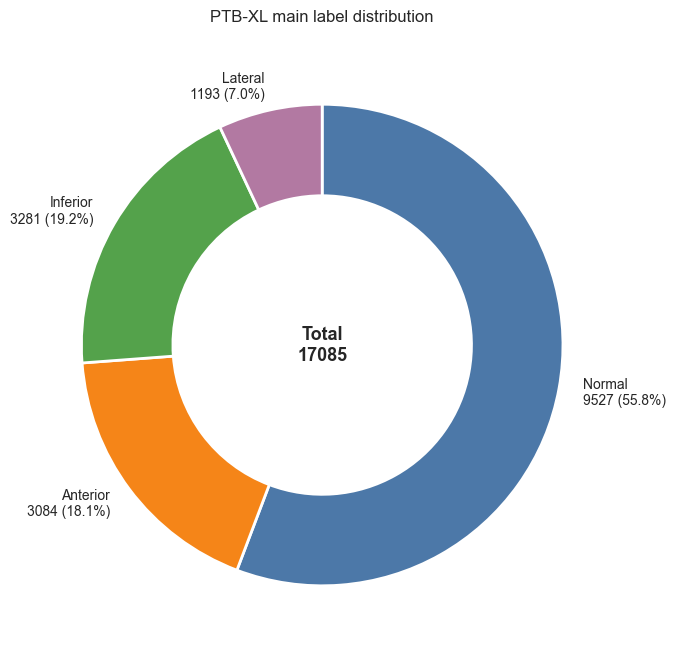

In [5]:
# Load PTB-XL metadata dan cek subclass/detail MI yang tersedia.
ptbxl_meta = pd.read_csv(PTB_XL_ROOT / 'ptbxl_database.csv', index_col='ecg_id')
ptbxl_meta['scp_codes'] = ptbxl_meta['scp_codes'].apply(ast.literal_eval)
scp_df = pd.read_csv(PTB_XL_ROOT / 'scp_statements.csv', index_col=0)
scp_diag = scp_df[scp_df['diagnostic'] == 1]

display(scp_diag[scp_diag['diagnostic_subclass'].isin(['NORM', 'AMI', 'IMI', 'LMI'])][['description', 'diagnostic_class', 'diagnostic_subclass']])
ptbxl_labels_all = prepare_dataset_labels(ptbxl_meta, 'ptb_xl', scp_diag=scp_diag)
ptbxl_validation = validate_label_mapping(ptbxl_labels_all, 'PTB-XL')
plot_label_distribution(ptbxl_labels_all, 'PTB-XL main label distribution', FIG_ROOT / 'ptbxl_main_label_distribution.png')

Load PTB-XL records: 100%|██████████| 15002/15002 [00:31<00:00, 478.43it/s]


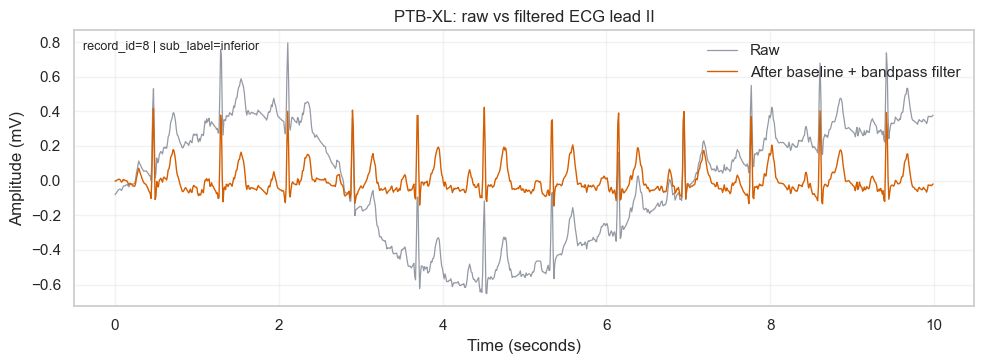

Saved: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/figures/data_prep/ptbxl_raw_vs_filtered_lead_II.png


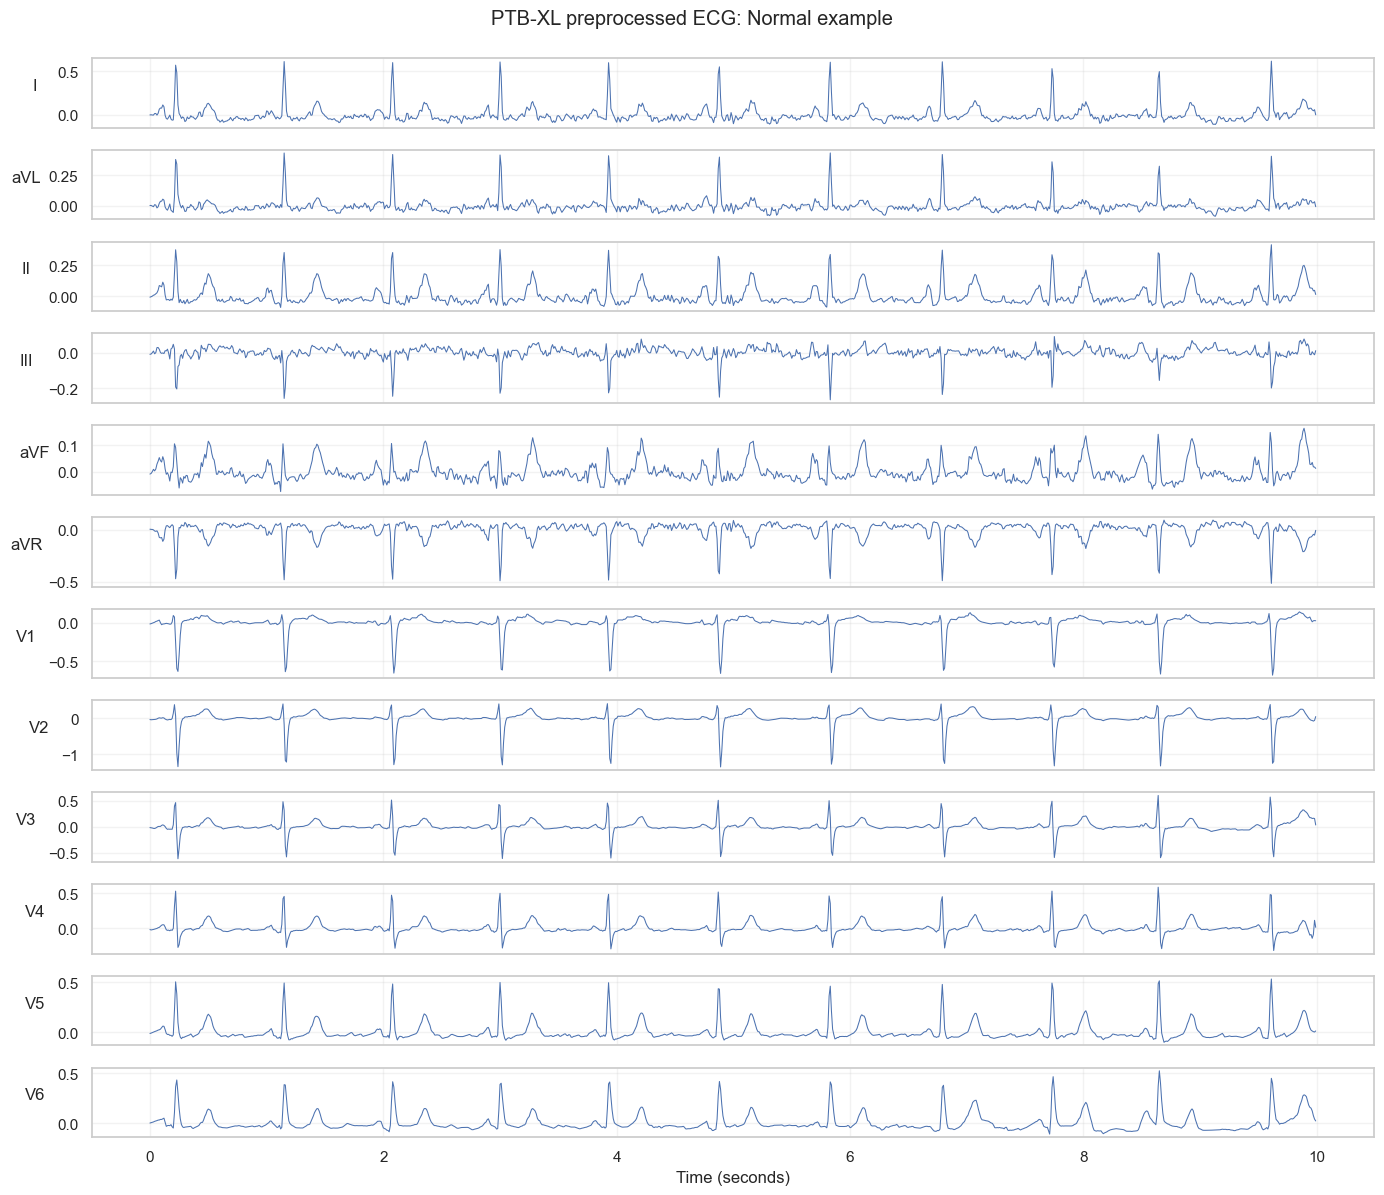

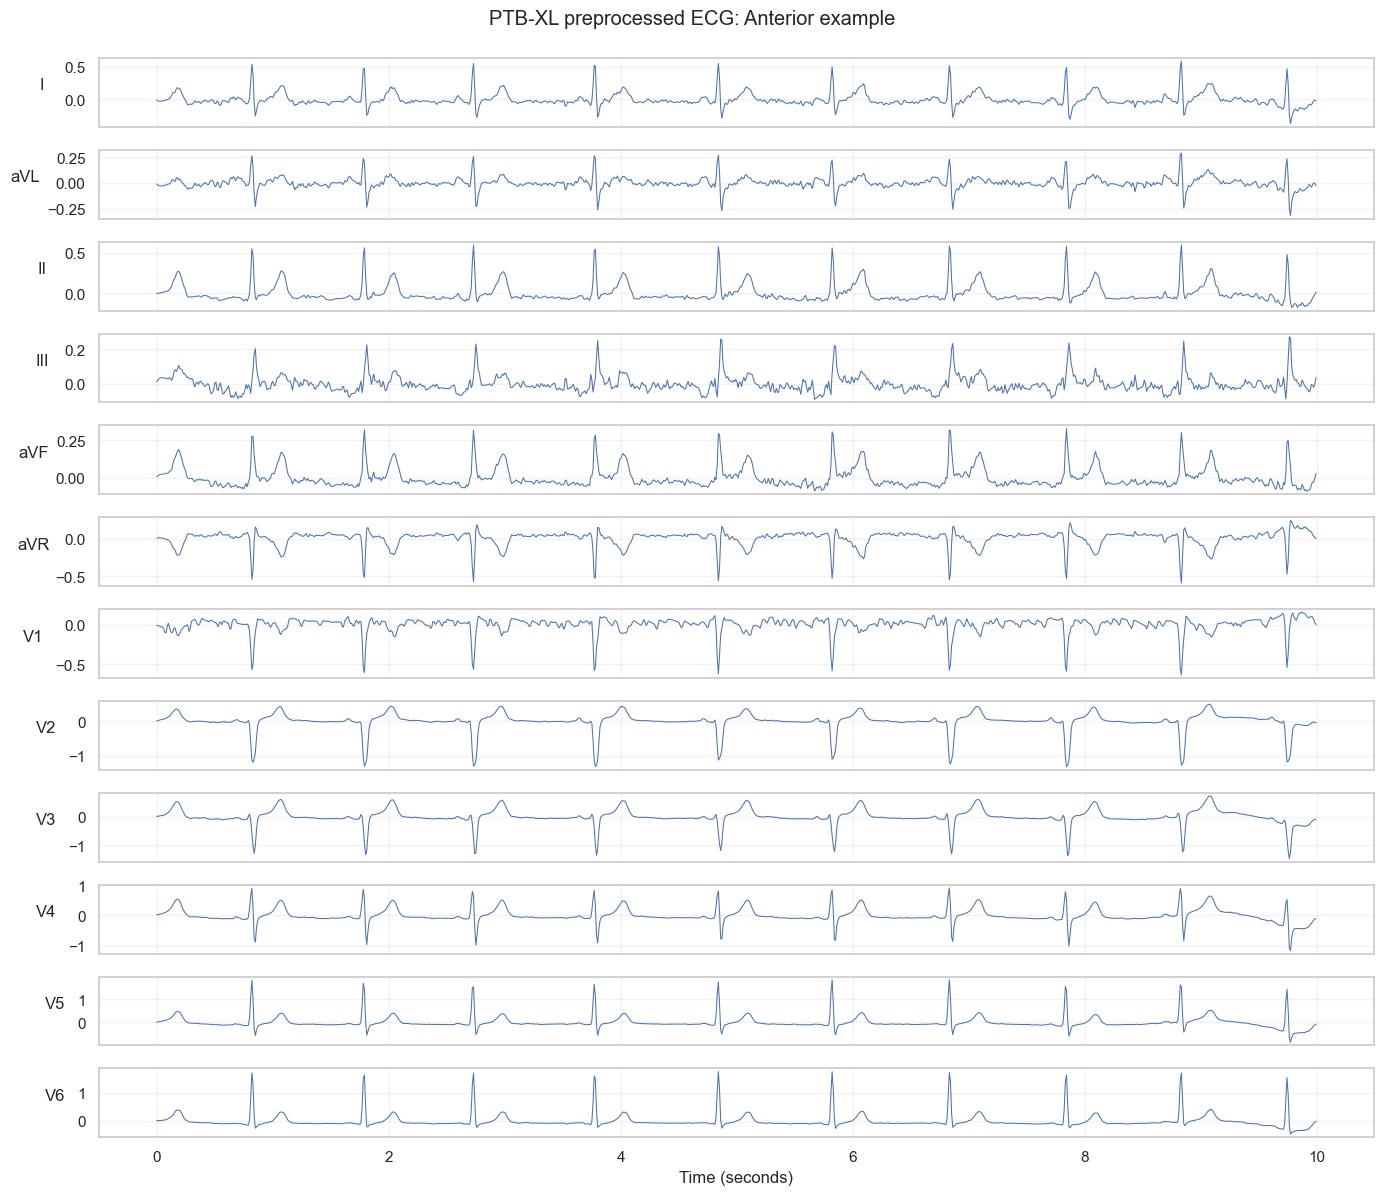

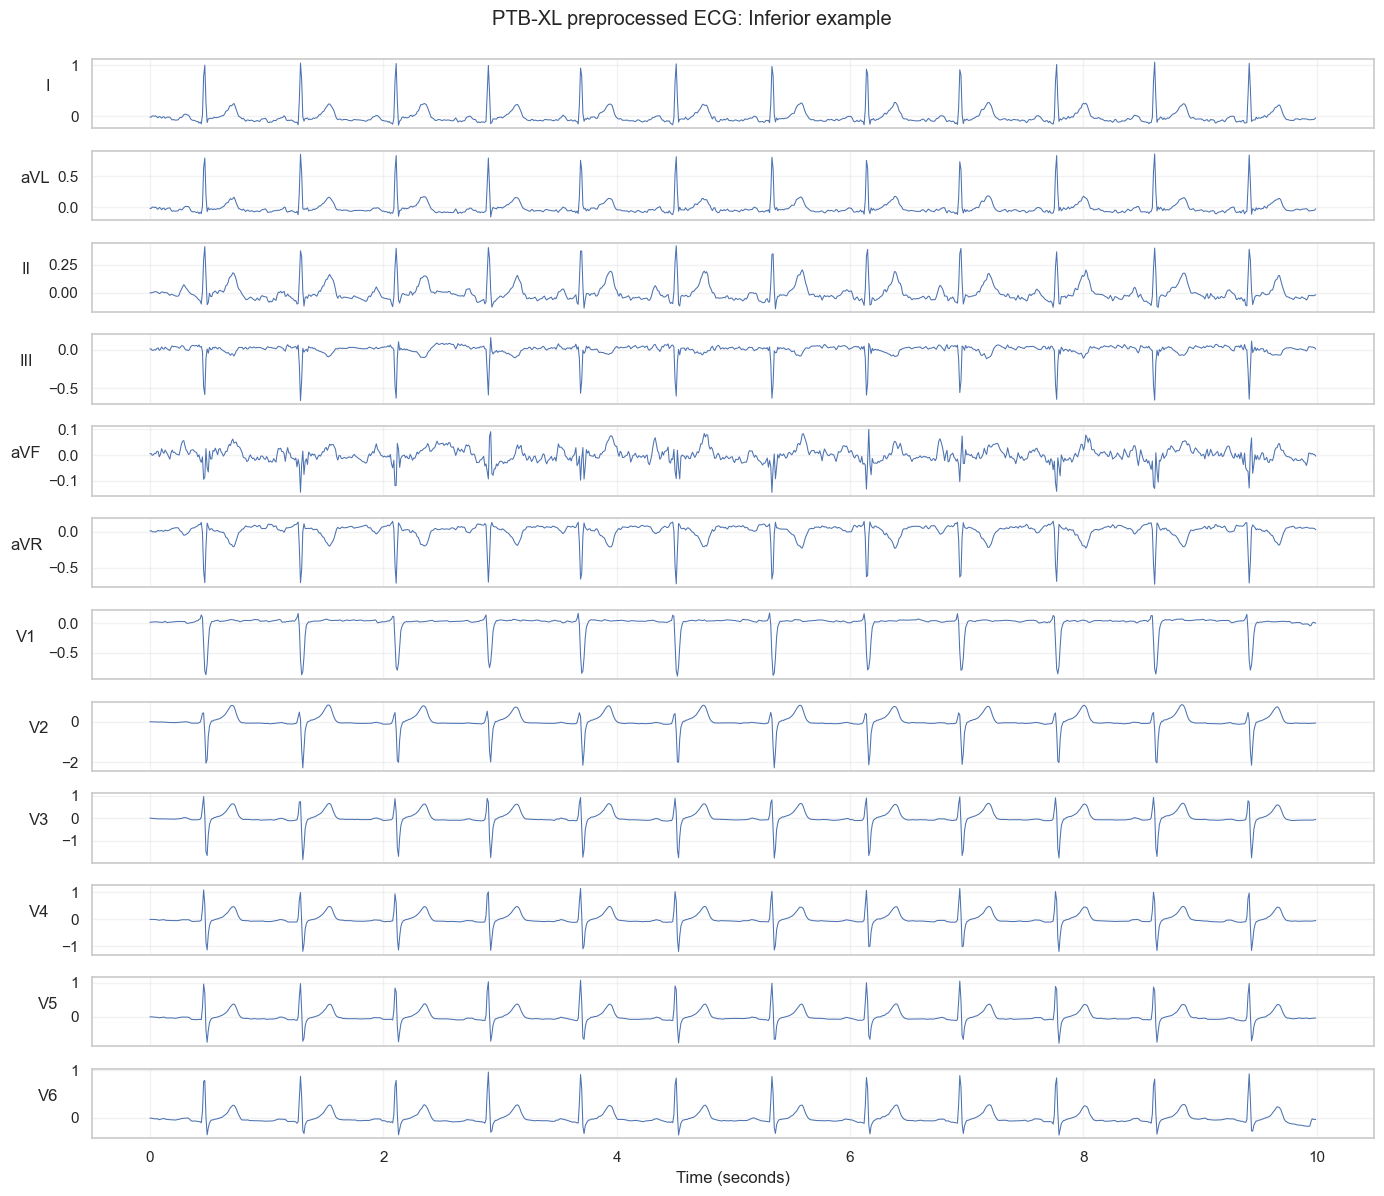

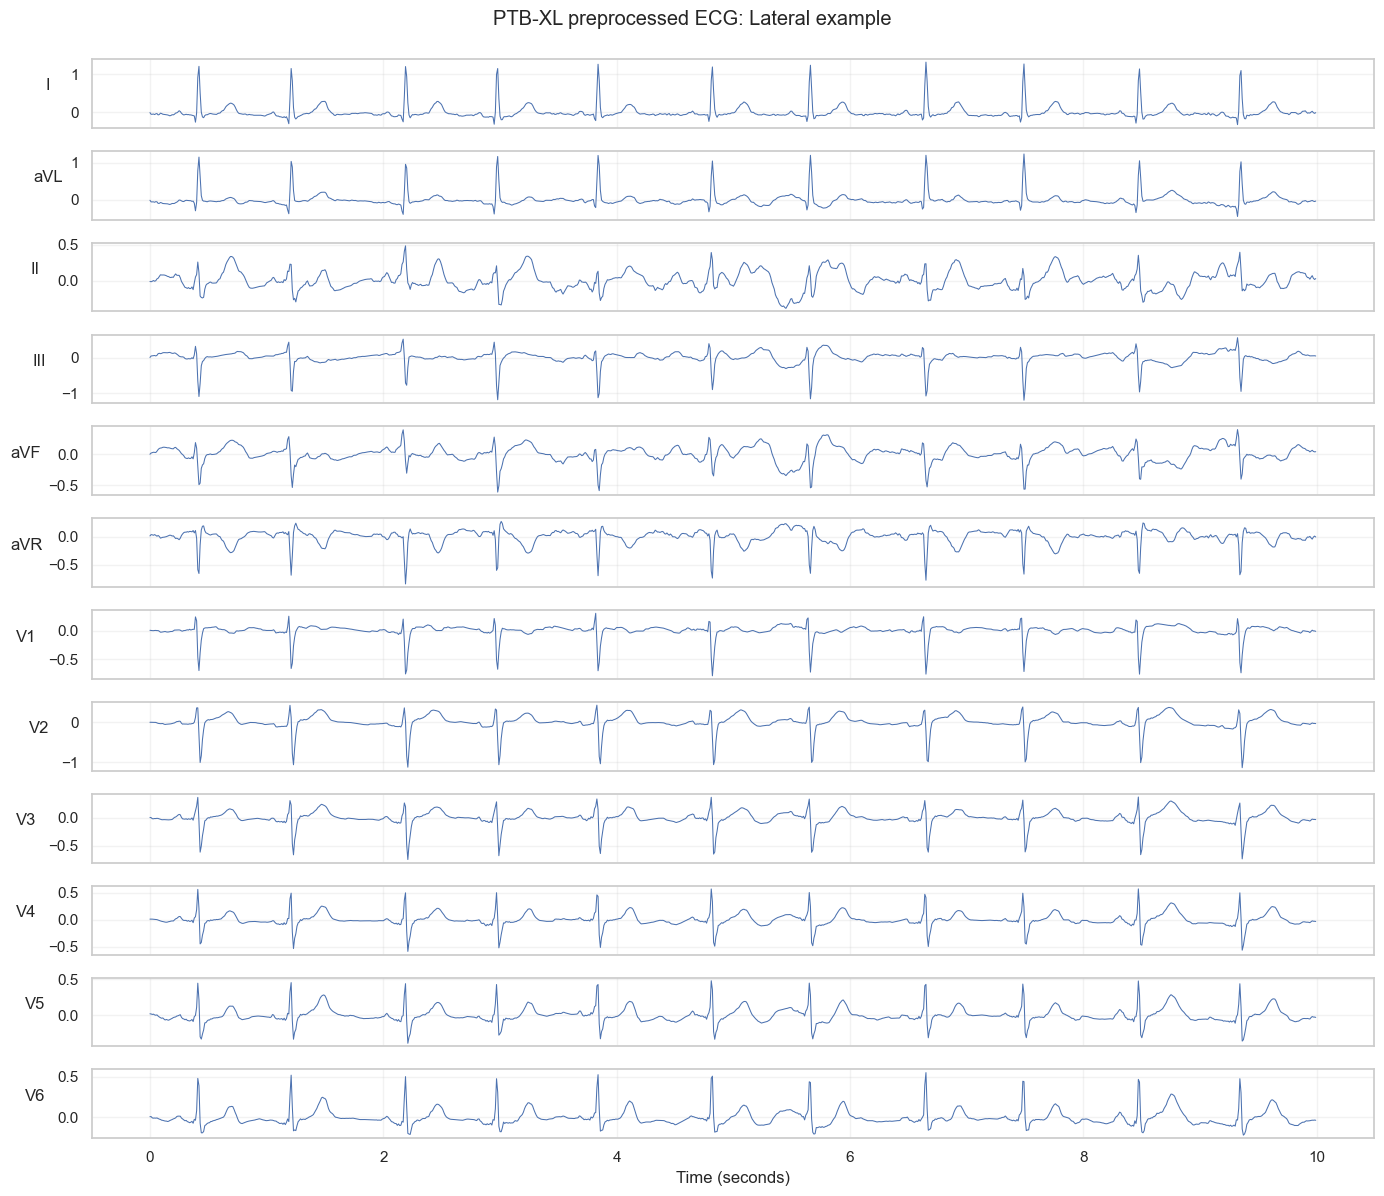

In [6]:
# Load dan preprocess sinyal PTB-XL sesuai label target universal.
ptbxl_selected_meta = ptbxl_meta.loc[ptbxl_labels_all['record_id'].to_numpy()].copy()
ptbxl_x_raw = load_ptbxl_raw_data(ptbxl_selected_meta, SAMPLING_RATE, PTB_XL_ROOT)
ptbxl_x_ready = preprocess_batch(ptbxl_x_raw, fs=SAMPLING_RATE)
ptbxl_meta_export = ptbxl_selected_meta.reset_index().rename(columns={'ecg_id': 'record_id'})
ptbxl_meta_export['patient_id'] = ptbxl_labels_all['patient_id'].to_numpy()
plot_raw_vs_filtered_lead(
    ptbxl_x_raw,
    ptbxl_x_ready,
    ptbxl_labels_all,
    'PTB-XL',
    FIG_ROOT / 'ptbxl_raw_vs_filtered_lead_II.png',
    lead='II',
    fs=SAMPLING_RATE,
)
plot_sample_ecgs(ptbxl_x_ready, ptbxl_labels_all, 'PTB-XL preprocessed ECG', FIG_ROOT / 'ptbxl_examples', fs=SAMPLING_RATE)


In [7]:
# Split PTB-XL patient-wise memakai strat_fold resmi: 1-8 train, 9 val, 10 test.
ptbxl_splits = {
    'train': ptbxl_meta_export.index[ptbxl_meta_export['strat_fold'].between(1, 8)].to_numpy(),
    'val': ptbxl_meta_export.index[ptbxl_meta_export['strat_fold'].eq(9)].to_numpy(),
    'test': ptbxl_meta_export.index[ptbxl_meta_export['strat_fold'].eq(10)].to_numpy(),
}
validate_patient_split(ptbxl_meta_export, 'patient_id', ptbxl_splits)
print('PTB-XL patient-wise split audit')
display(split_summary(ptbxl_labels_all, ptbxl_splits))
save_dataset('ptb_xl', ptbxl_x_ready, ptbxl_labels_all, ptbxl_meta_export, ptbxl_splits)

PTB-XL patient-wise split audit


,split,records,Normal,Anterior,Inferior,Lateral
0,train,11986,7606,2469,2623,953
1,val,1500,957,307,330,121
2,test,1516,964,308,328,119


Saved dataset: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/dataset/ptb_xl


,split,records,Normal,Anterior,Inferior,Lateral
0,train,11986,7606,2469,2623,953
1,val,1500,957,307,330,121
2,test,1516,964,308,328,119


## PTB Diagnostic

=== PTB Diagnostic label validation ===
Samples: 444
Main label distribution:


,count
Normal,80
Anterior,190
Inferior,192
Lateral,139


Territory distribution:


,count
Anterior,190
Inferior,192
Lateral,139


Multi-territory samples: 152
First 10 mappings:


,record_id,dataset_source,raw_label,sub_label,main_label_vector,territory_vector,lead_prior_vector,fold
0,s0010_re,ptb_diagnostic,Myocardial infarction|infero-latera|no,infero-latera,"[0, 0, 1, 1]","[0, 1, 1]","[0.14285715, 0.14285715, 0.14285715, 0.1428571...",NaN
1,s0014lre,ptb_diagnostic,Myocardial infarction|infero-latera|no,infero-latera,"[0, 0, 1, 1]","[0, 1, 1]","[0.14285715, 0.14285715, 0.14285715, 0.1428571...",NaN
2,s0016lre,ptb_diagnostic,Myocardial infarction|infero-latera|no,infero-latera,"[0, 0, 1, 1]","[0, 1, 1]","[0.14285715, 0.14285715, 0.14285715, 0.1428571...",NaN
3,s0015lre,ptb_diagnostic,Myocardial infarction|anterior|no,anterior,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2...",NaN
4,s0017lre,ptb_diagnostic,Myocardial infarction|infero-postero-lateral|no,infero-postero-lateral,"[0, 0, 1, 1]","[0, 1, 1]","[0.14285715, 0.14285715, 0.14285715, 0.1428571...",NaN
5,s0020are,ptb_diagnostic,Myocardial infarction|antero-septal|no,antero-septal,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2...",NaN
6,s0020bre,ptb_diagnostic,Myocardial infarction|antero-septal|no,antero-septal,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2...",NaN
7,s0021are,ptb_diagnostic,Myocardial infarction|anterior|no,anterior,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2...",NaN
8,s0021bre,ptb_diagnostic,Myocardial infarction|anterior|no,anterior,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2...",NaN
9,s0025lre,ptb_diagnostic,Myocardial infarction|anterior|no,anterior,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2...",NaN


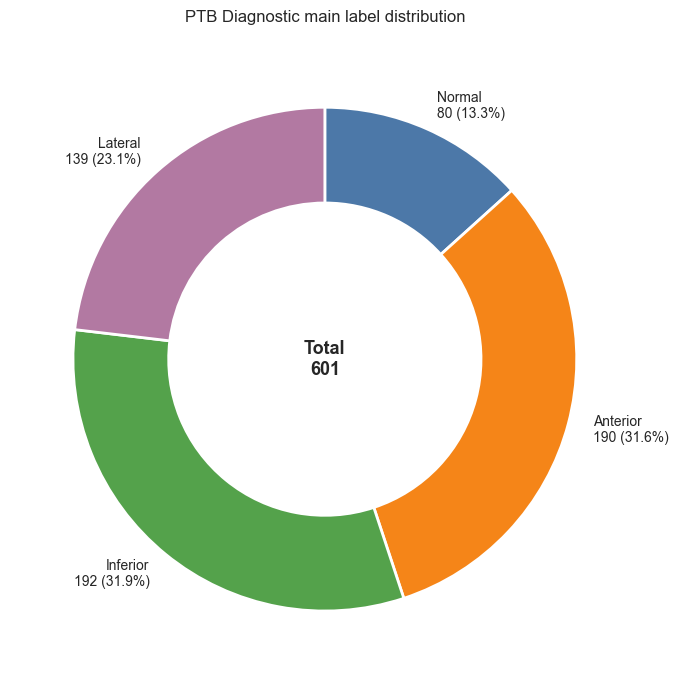

In [8]:
# Load PTB Diagnostic metadata dan mapping label universal.
ptb_diag_meta = pd.read_csv(PTB_DIAGNOSTIC_ROOT / 'meta.csv')
ptb_diag_raw = np.load(PTB_DIAGNOSTIC_ROOT / 'data_raw.npz')
ptb_diag_labels_all = prepare_dataset_labels(ptb_diag_meta, 'ptb_diagnostic')
ptb_diag_validation = validate_label_mapping(ptb_diag_labels_all, 'PTB Diagnostic')
plot_label_distribution(ptb_diag_labels_all, 'PTB Diagnostic main label distribution', FIG_ROOT / 'ptb_diagnostic_main_label_distribution.png')

Prepare PTB Diagnostic: 100%|██████████| 444/444 [00:08<00:00, 54.91it/s]


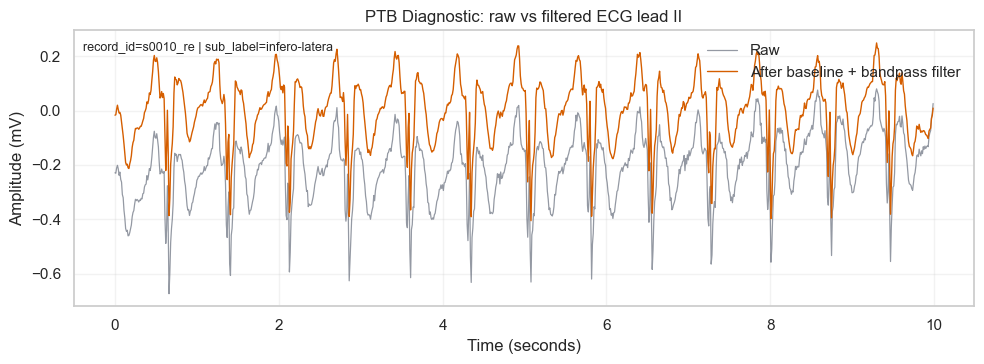

Saved: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/figures/data_prep/ptb_diagnostic_raw_vs_filtered_lead_II.png


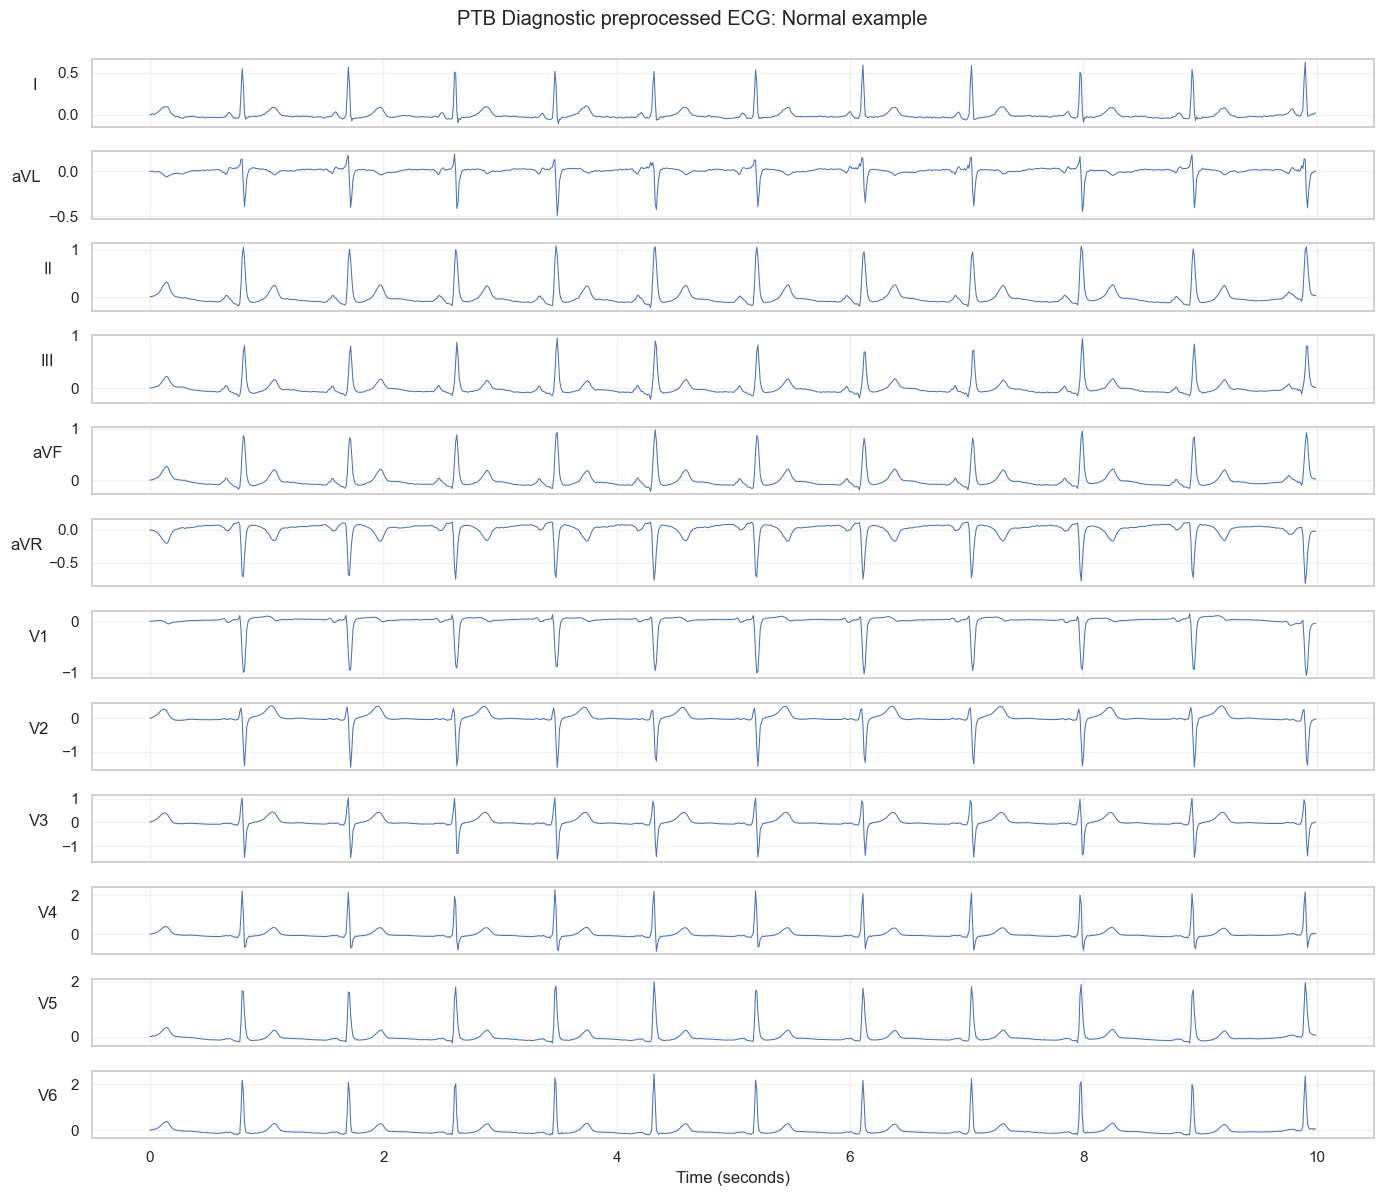

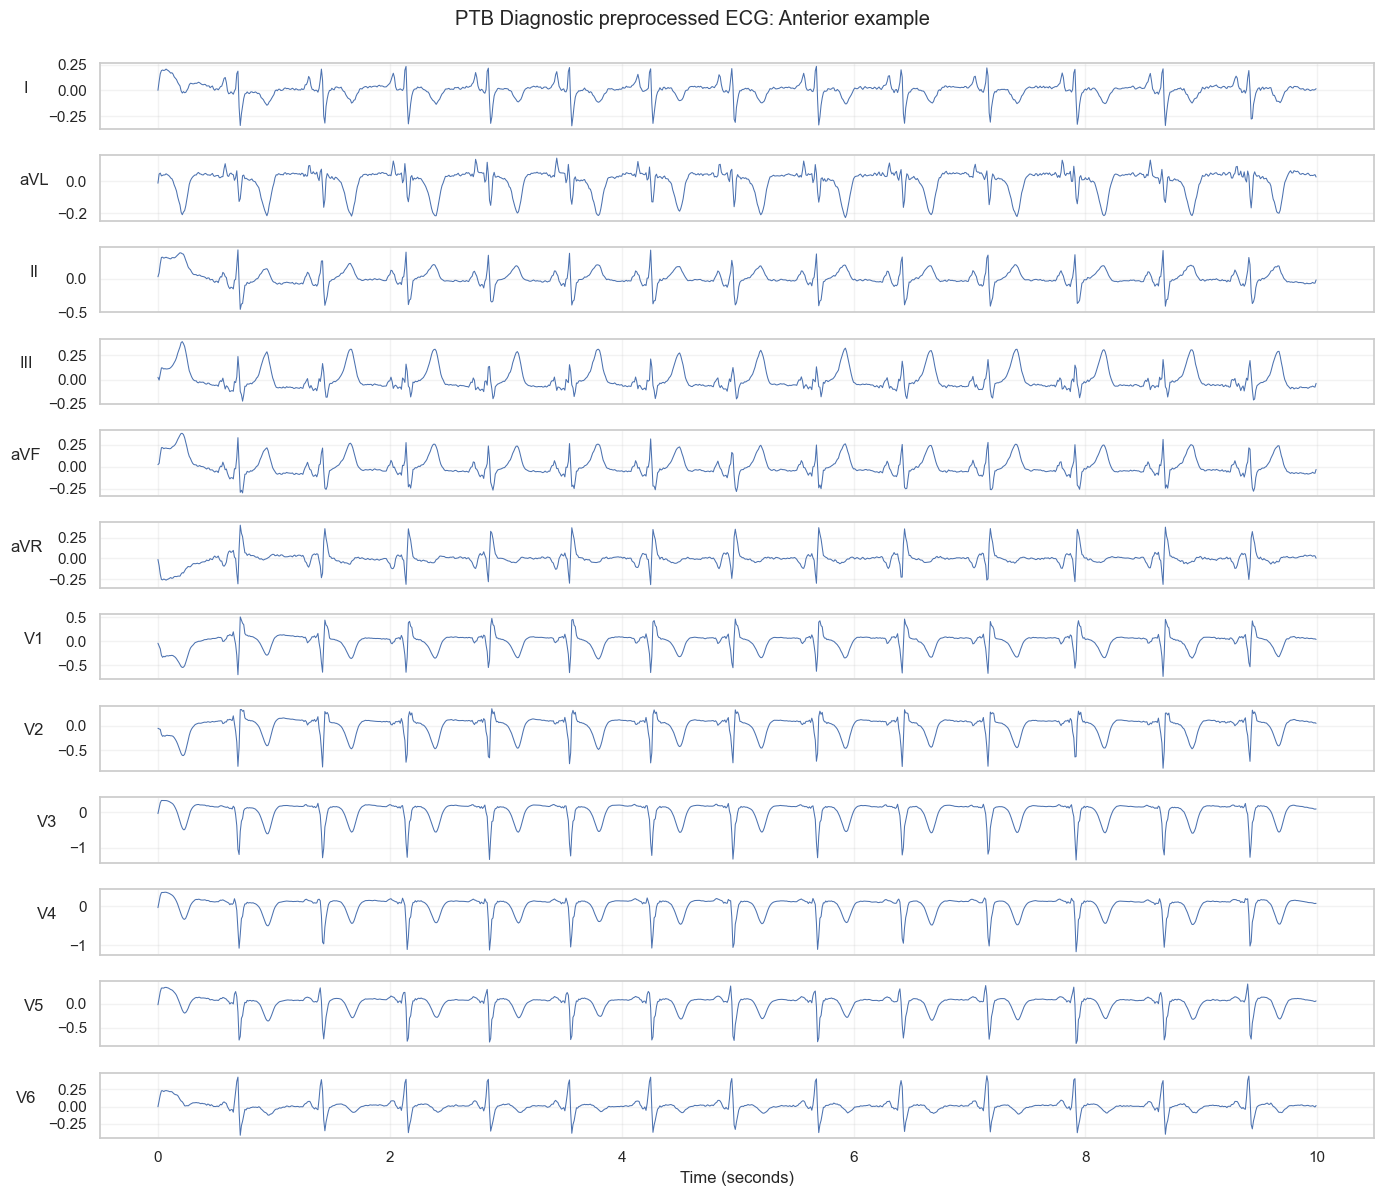

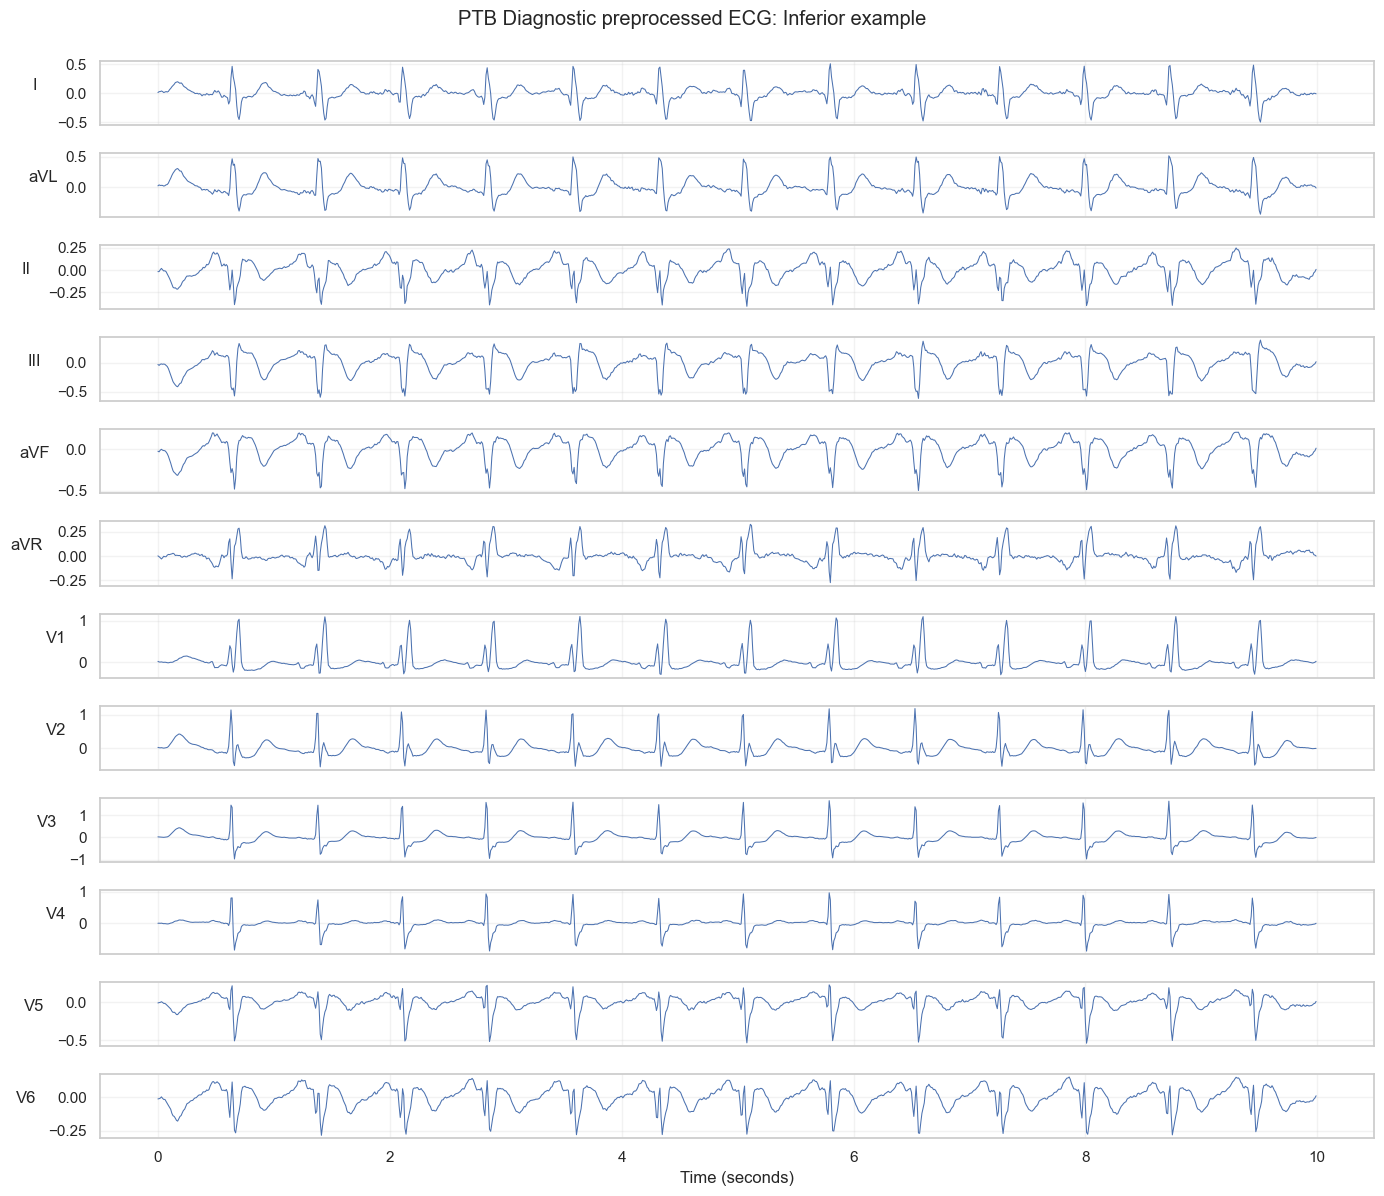

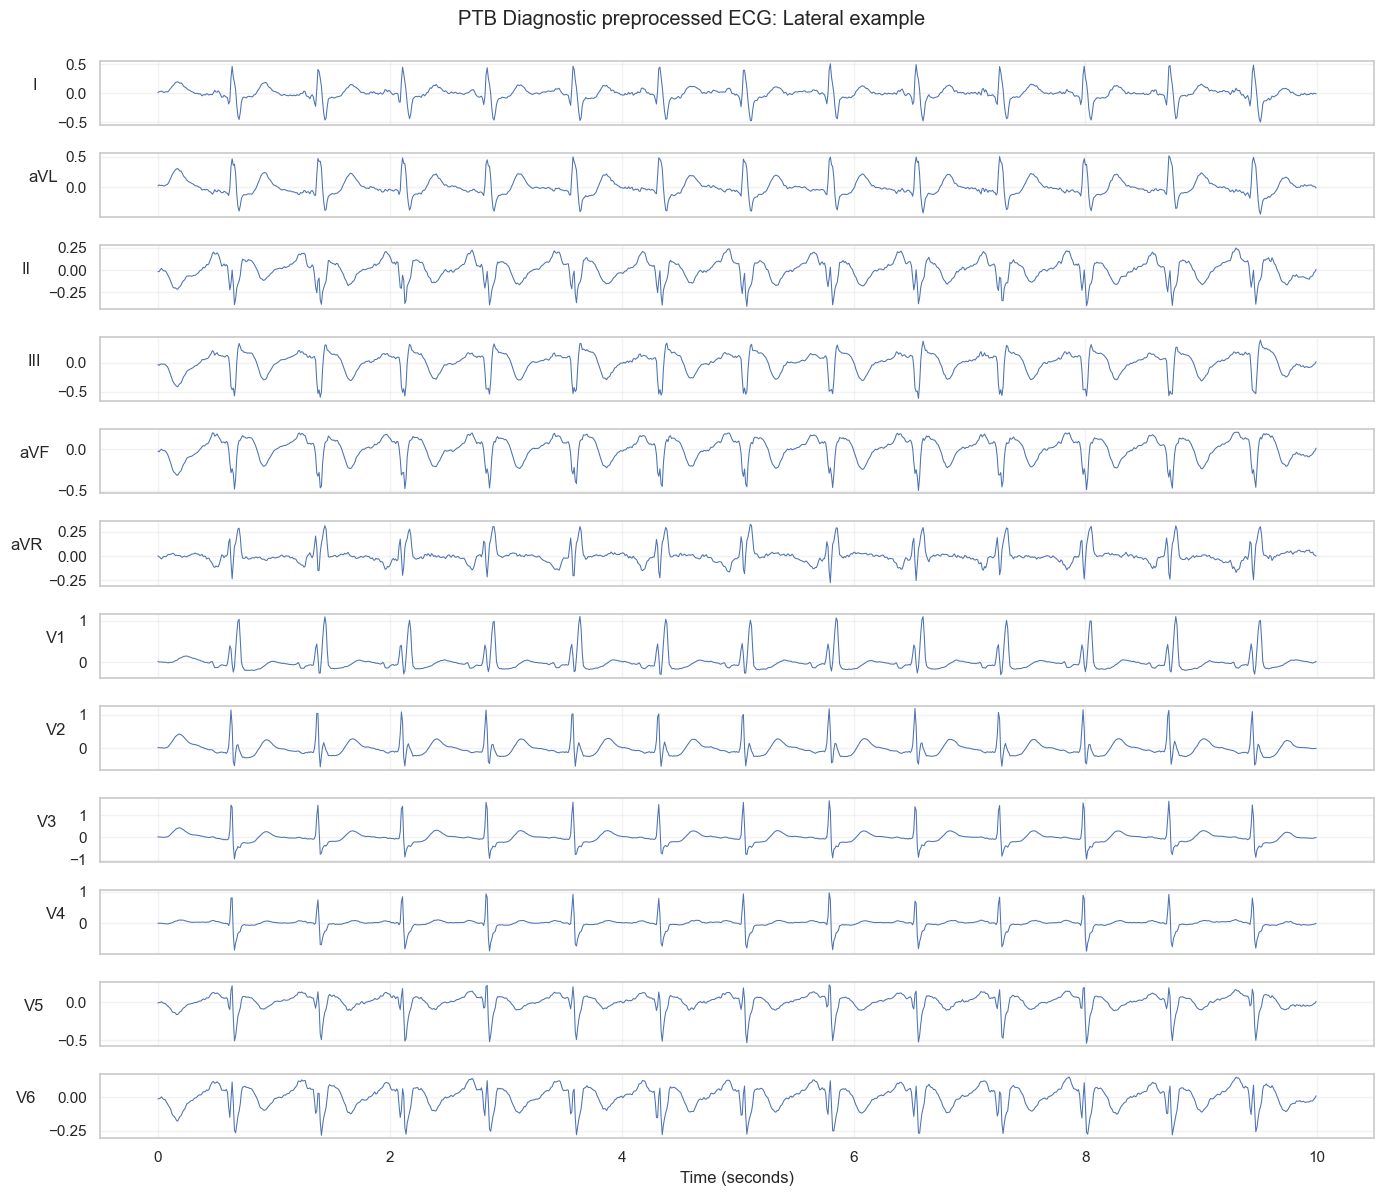

In [9]:
# Downsample PTB Diagnostic ke 100 Hz, reorder lead ALPA, potong/pad 10 detik, lalu preprocess.
def prepare_ptb_diagnostic_signal(row):
    record_key = f"{row['patient']}/{row['record_id']}"
    signal = ptb_diag_raw[record_key]
    sig_names = ast.literal_eval(row['sig_name']) if isinstance(row['sig_name'], str) else row['sig_name']
    validate_source_lead_order(sig_names, record_key)
    fs = int(row['fs'])
    if fs % SAMPLING_RATE != 0:
        raise ValueError(f'{record_key}: fs {fs} cannot be downsampled to {SAMPLING_RATE} with integer factor.')
    signal_100hz = reorder_to_alpa_leads(signal[::fs // SAMPLING_RATE, :len(SOURCE_LEAD_ORDER)])
    if signal_100hz.shape[0] < SEGMENT_LEN:
        out = np.zeros((SEGMENT_LEN, len(ALPA_LEAD_ORDER)), dtype=signal_100hz.dtype)
        out[:signal_100hz.shape[0]] = signal_100hz
        return out
    return signal_100hz[:SEGMENT_LEN]

if 'source_index' in ptb_diag_labels_all.columns:
    ptb_diag_selected_meta = ptb_diag_meta.loc[ptb_diag_labels_all['source_index'].to_numpy()].copy().reset_index(drop=True)
else:
    # Backward-compatible fallback if labels were created before source_index existed.
    label_keys = ptb_diag_labels_all['signal_path'].astype(str)
    meta_keys = ptb_diag_meta['patient'].astype(str) + '/' + ptb_diag_meta['record_id'].astype(str)
    key_to_index = pd.Series(ptb_diag_meta.index.to_numpy(), index=meta_keys)
    missing_keys = sorted(set(label_keys) - set(key_to_index.index))
    if missing_keys:
        raise KeyError(f'Cannot map PTB Diagnostic signal_path to metadata rows. Missing keys: {missing_keys[:5]}')
    ptb_diag_selected_meta = ptb_diag_meta.loc[key_to_index.loc[label_keys].to_numpy()].copy().reset_index(drop=True)
ptb_diag_x_raw_100hz = np.stack([
    prepare_ptb_diagnostic_signal(row)
    for _, row in tqdm(ptb_diag_selected_meta.iterrows(), total=len(ptb_diag_selected_meta), desc='Prepare PTB Diagnostic')
]).astype(np.float32)
ptb_diag_x_ready = preprocess_batch(ptb_diag_x_raw_100hz, fs=SAMPLING_RATE)
plot_raw_vs_filtered_lead(
    ptb_diag_x_raw_100hz,
    ptb_diag_x_ready,
    ptb_diag_labels_all,
    'PTB Diagnostic',
    FIG_ROOT / 'ptb_diagnostic_raw_vs_filtered_lead_II.png',
    lead='II',
    fs=SAMPLING_RATE,
)
plot_sample_ecgs(ptb_diag_x_ready, ptb_diag_labels_all, 'PTB Diagnostic preprocessed ECG', FIG_ROOT / 'ptb_diagnostic_examples', fs=SAMPLING_RATE)


In [10]:
# Split PTB Diagnostic patient-wise dan ekspor format yang sama dengan PTB-XL.
ptb_diag_splits = patient_wise_split(
    ptb_diag_selected_meta,
    patient_col='patient',
    test_size=TEST_SIZE,
    val_size_from_remaining=VAL_SIZE_FROM_REMAINING,
    seed=RANDOM_STATE,
)
print('PTB Diagnostic patient-wise split audit')
display(split_summary(ptb_diag_labels_all, ptb_diag_splits))
save_dataset('ptb_diagnostic', ptb_diag_x_ready, ptb_diag_labels_all, ptb_diag_selected_meta, ptb_diag_splits)

PTB Diagnostic patient-wise split audit


,split,records,Normal,Anterior,Inferior,Lateral
0,train,317,64,136,138,90
1,val,38,5,20,11,15
2,test,89,11,34,43,34


Saved dataset: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/dataset/ptb_diagnostic


,split,records,Normal,Anterior,Inferior,Lateral
0,train,317,64,136,138,90
1,val,38,5,20,11,15
2,test,89,11,34,43,34


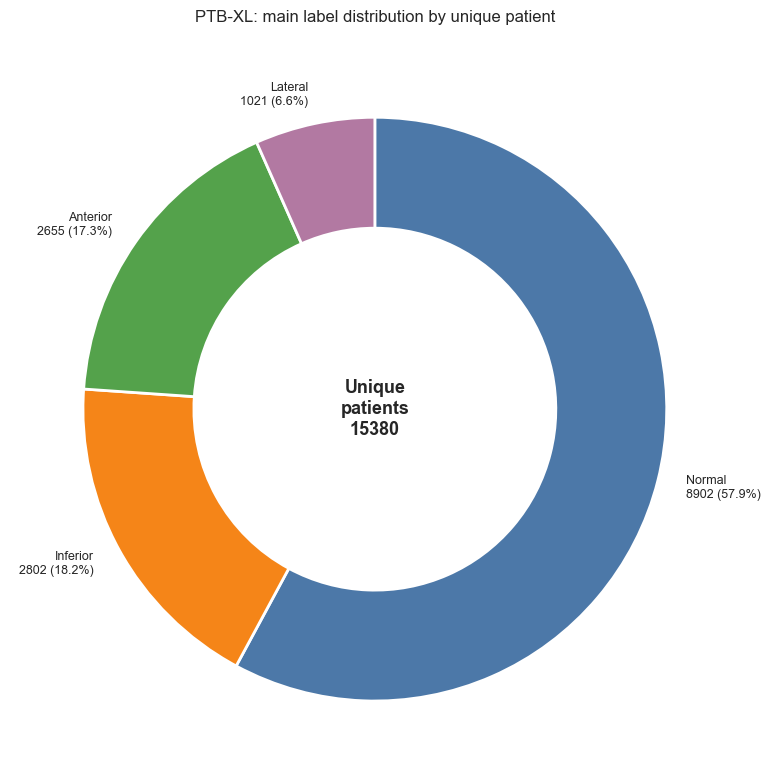

Saved: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/figures/data_prep/ptb_xl_patient_main_label_ring.png


,label,patient_count
0,Normal,8902
2,Inferior,2802
1,Anterior,2655
3,Lateral,1021


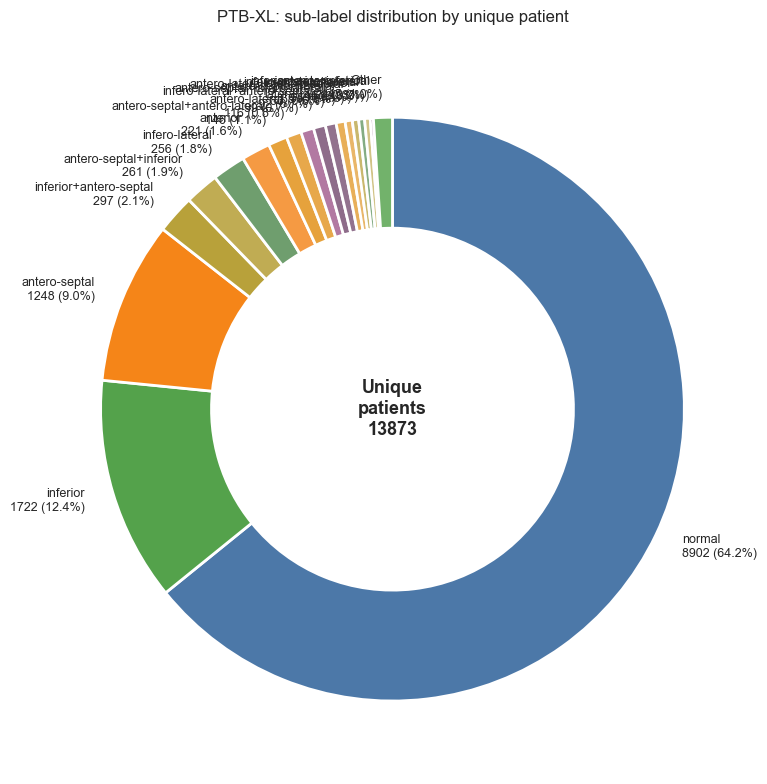

Saved: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/figures/data_prep/ptb_xl_patient_sub_label_ring.png


,sub_label,patient_count
0,normal,8902
1,inferior,1722
2,antero-septal,1248
3,inferior+antero-septal,297
4,antero-septal+inferior,261
5,infero-lateral,256
6,anterior,221
7,antero-septal+antero-lateral,146
8,antero-lateral,116
9,lateral,99


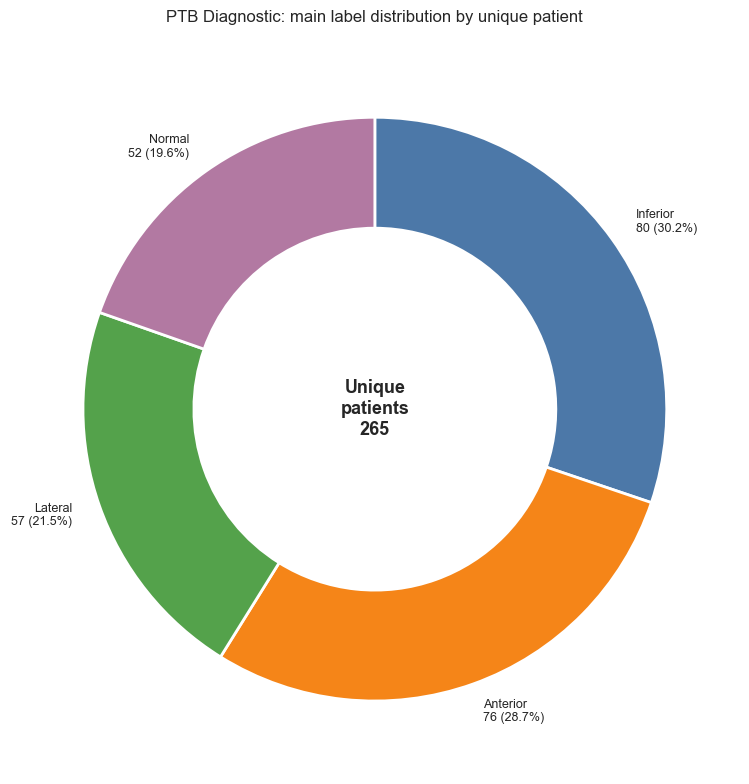

Saved: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/figures/data_prep/ptb_diagnostic_patient_main_label_ring.png


,label,patient_count
2,Inferior,80
1,Anterior,76
3,Lateral,57
0,Normal,52


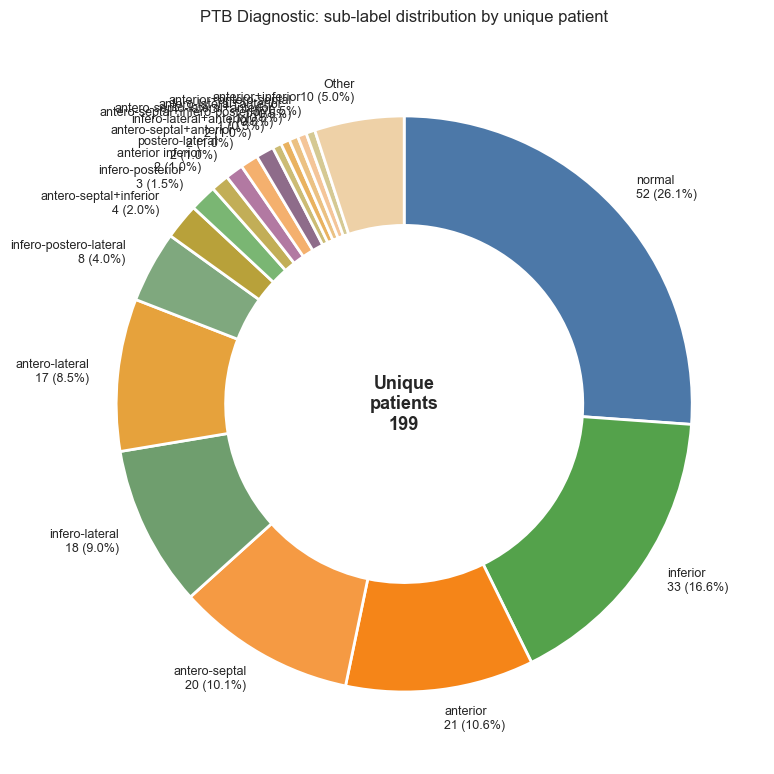

Saved: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/figures/data_prep/ptb_diagnostic_patient_sub_label_ring.png


,sub_label,patient_count
0,normal,52
1,inferior,33
2,anterior,21
3,antero-septal,20
4,infero-lateral,18
5,antero-lateral,17
6,infero-postero-lateral,8
7,antero-septal+inferior,4
8,infero-posterior,3
9,anterior inferior,2


In [11]:
# Plot distribusi berbasis pasien unik dan distribusi sub-label per dataset.
def parse_vector_column(series, dtype=np.int8):
    return np.stack(series.apply(lambda x: np.array(json.loads(x), dtype=dtype)).to_numpy())

def patient_main_label_counts(label_df):
    main = parse_vector_column(label_df['main_label_vector'], np.int8)
    rows = []
    for idx, label in enumerate(MAIN_LABEL_COLUMNS):
        active = main[:, idx] == 1
        rows.append({'label': label, 'patient_count': label_df.loc[active, 'patient_id'].astype(str).nunique()})
    return pd.DataFrame(rows)

def patient_sub_label_counts(label_df):
    df = label_df[['patient_id', 'sub_label', 'main_label_vector', 'territory_vector']].copy()
    df['patient_id'] = df['patient_id'].astype(str)
    df = df.drop_duplicates(['patient_id', 'sub_label'])
    counts = df.groupby('sub_label', as_index=False).agg(patient_count=('patient_id', 'nunique'))
    counts = counts.sort_values('patient_count', ascending=False).reset_index(drop=True)
    return counts

def sub_label_group(sub_label):
    territory = map_to_territory_vector(sub_label)
    if normalize_label_text(sub_label) == 'normal' and territory.sum() == 0:
        return 'Normal'
    active = [name for name, flag in zip(TERRITORY_COLUMNS, territory) if flag == 1]
    if len(active) == 0:
        return 'Other'
    if len(active) > 1:
        return '+'.join(active)
    return active[0]

def colors_for_sub_labels(sub_labels):
    base = {
        'Normal': '#4C78A8',
        'Anterior': '#F58518',
        'Inferior': '#54A24B',
        'Lateral': '#B279A2',
        'Anterior+Lateral': '#E6A23C',
        'Inferior+Lateral': '#6F9E6E',
        'Anterior+Inferior': '#B8A13A',
        'Anterior+Inferior+Lateral': '#8E6C8A',
        'Other': '#9CA3AF',
    }
    groups = [sub_label_group(item) for item in sub_labels]
    color_map = {}
    for group in sorted(set(groups)):
        items = [item for item, item_group in zip(sub_labels, groups) if item_group == group]
        palette = sns.light_palette(base.get(group, '#9CA3AF'), n_colors=len(items) + 2, reverse=True)
        for item, color in zip(items, palette[:len(items)]):
            color_map[item] = color
    return [color_map[item] for item in sub_labels]

def plot_patient_ring(counts_df, label_col, count_col, title, output_path, colors=None, max_slices=None):
    plot_df = counts_df.copy().sort_values(count_col, ascending=False)
    if max_slices is not None and len(plot_df) > max_slices:
        head = plot_df.iloc[:max_slices].copy()
        other_count = int(plot_df.iloc[max_slices:][count_col].sum())
        plot_df = pd.concat([head, pd.DataFrame([{label_col: 'Other', count_col: other_count}])], ignore_index=True)
    total = int(plot_df[count_col].sum())
    labels = [f'{row[label_col]}\n{int(row[count_col])} ({row[count_col] / total:.1%})' for _, row in plot_df.iterrows()]
    if colors is None:
        colors = sns.color_palette('Set2', n_colors=len(plot_df))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(
        plot_df[count_col].to_numpy(),
        labels=labels,
        startangle=90,
        counterclock=False,
        colors=colors,
        wedgeprops={'width': 0.38, 'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 9},
    )
    ax.text(0, 0, f'Unique\npatients\n{total}', ha='center', va='center', fontsize=13, fontweight='bold')
    ax.set_title(title, pad=16)
    ax.set_aspect('equal')
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved:', output_path)
    display(plot_df)

def plot_patient_distributions_from_saved_dataset(dataset_name, title):
    label_path = OUTPUT_ROOT / dataset_name / 'labels_all.csv'
    labels = pd.read_csv(label_path)
    main_counts = patient_main_label_counts(labels)
    main_colors = ['#4C78A8', '#F58518', '#54A24B', '#B279A2']
    plot_patient_ring(
        main_counts,
        'label',
        'patient_count',
        f'{title}: main label distribution by unique patient',
        FIG_ROOT / f'{dataset_name}_patient_main_label_ring.png',
        colors=main_colors,
    )

    sub_counts = patient_sub_label_counts(labels)
    sub_colors = colors_for_sub_labels(sub_counts['sub_label'].tolist())
    plot_patient_ring(
        sub_counts,
        'sub_label',
        'patient_count',
        f'{title}: sub-label distribution by unique patient',
        FIG_ROOT / f'{dataset_name}_patient_sub_label_ring.png',
        colors=sub_colors,
        max_slices=18,
    )
    sub_counts.to_csv(FIG_ROOT / f'{dataset_name}_patient_sub_label_counts.csv', index=False)
    main_counts.to_csv(FIG_ROOT / f'{dataset_name}_patient_main_label_counts.csv', index=False)
    return main_counts, sub_counts

ptbxl_patient_main_counts, ptbxl_patient_sub_counts = plot_patient_distributions_from_saved_dataset('ptb_xl', 'PTB-XL')
ptbdiag_patient_main_counts, ptbdiag_patient_sub_counts = plot_patient_distributions_from_saved_dataset('ptb_diagnostic', 'PTB Diagnostic')

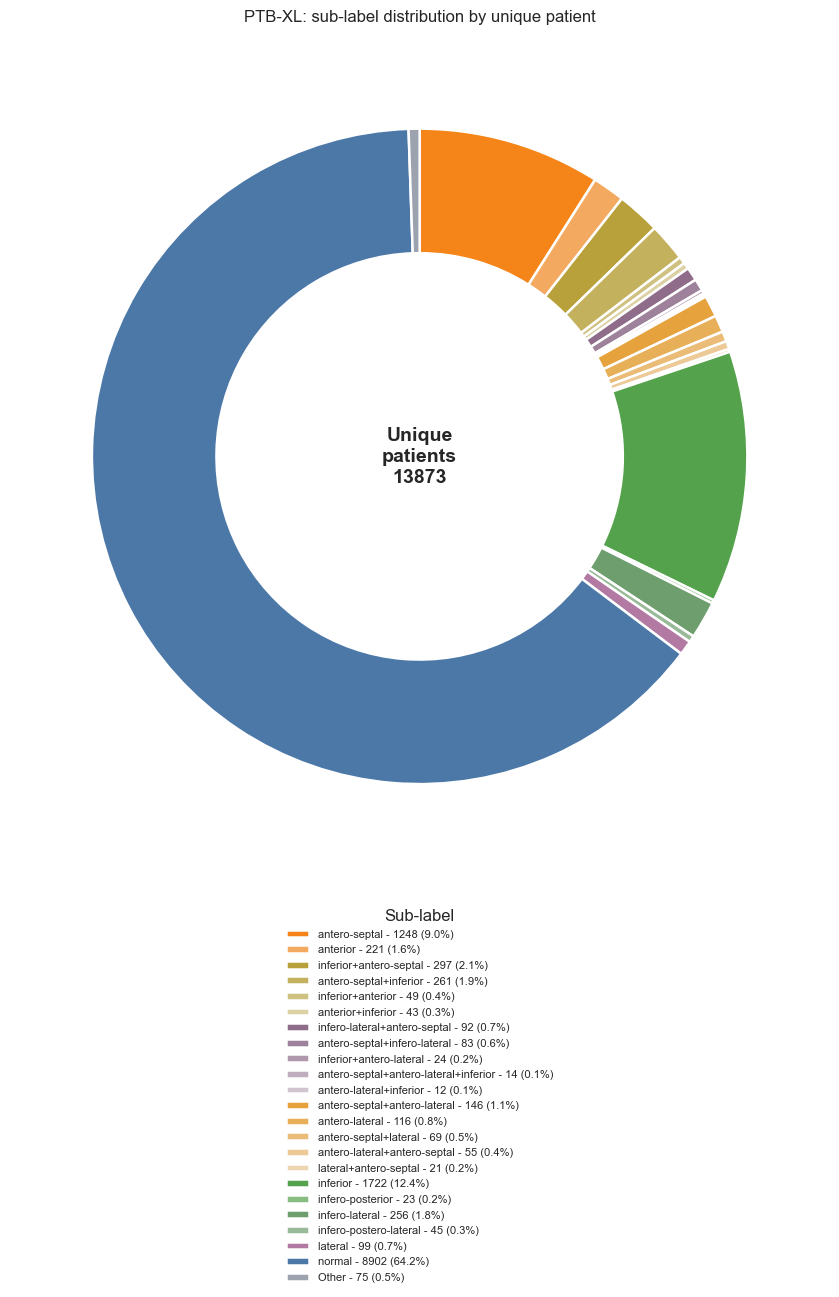

Saved: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/figures/data_prep/ptb_xl_patient_sub_label_ring_legend.png


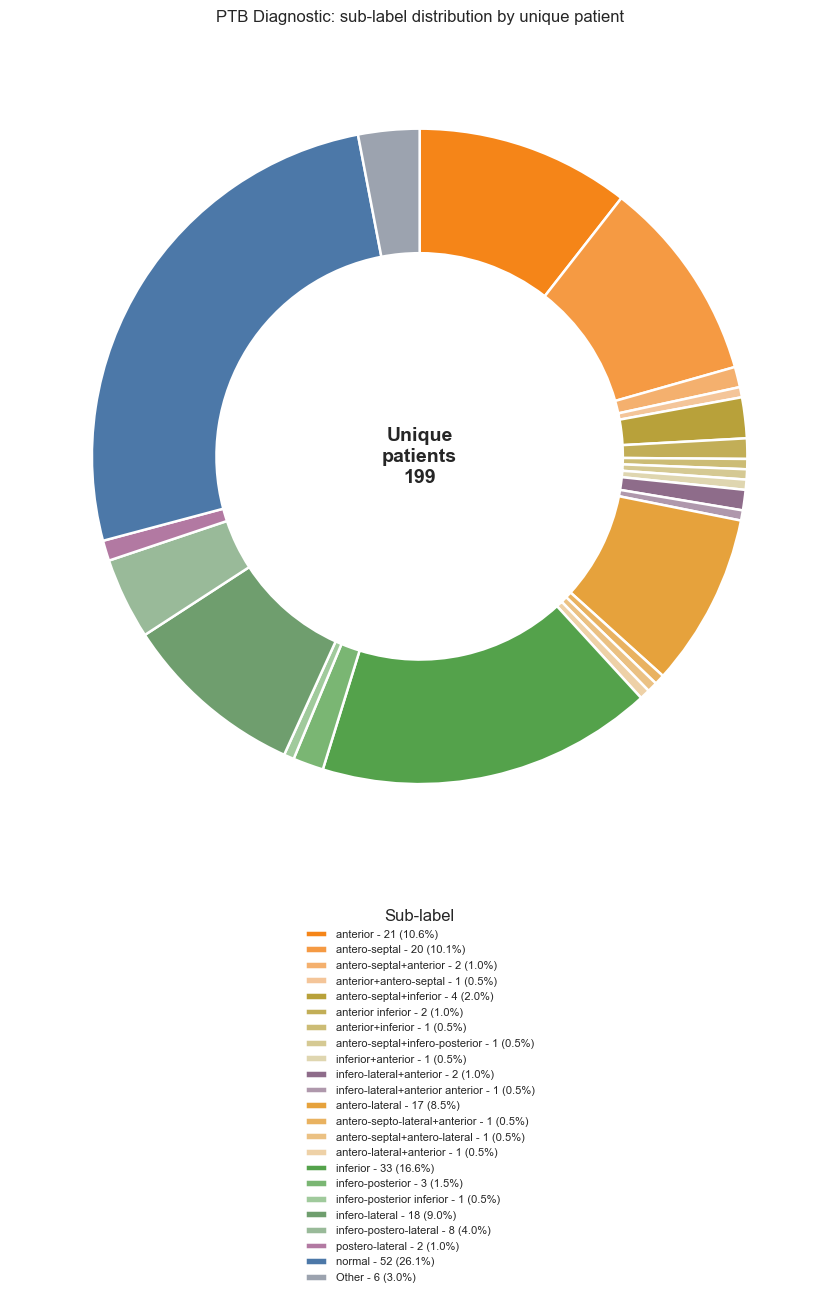

Saved: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/figures/data_prep/ptb_diagnostic_patient_sub_label_ring_legend.png


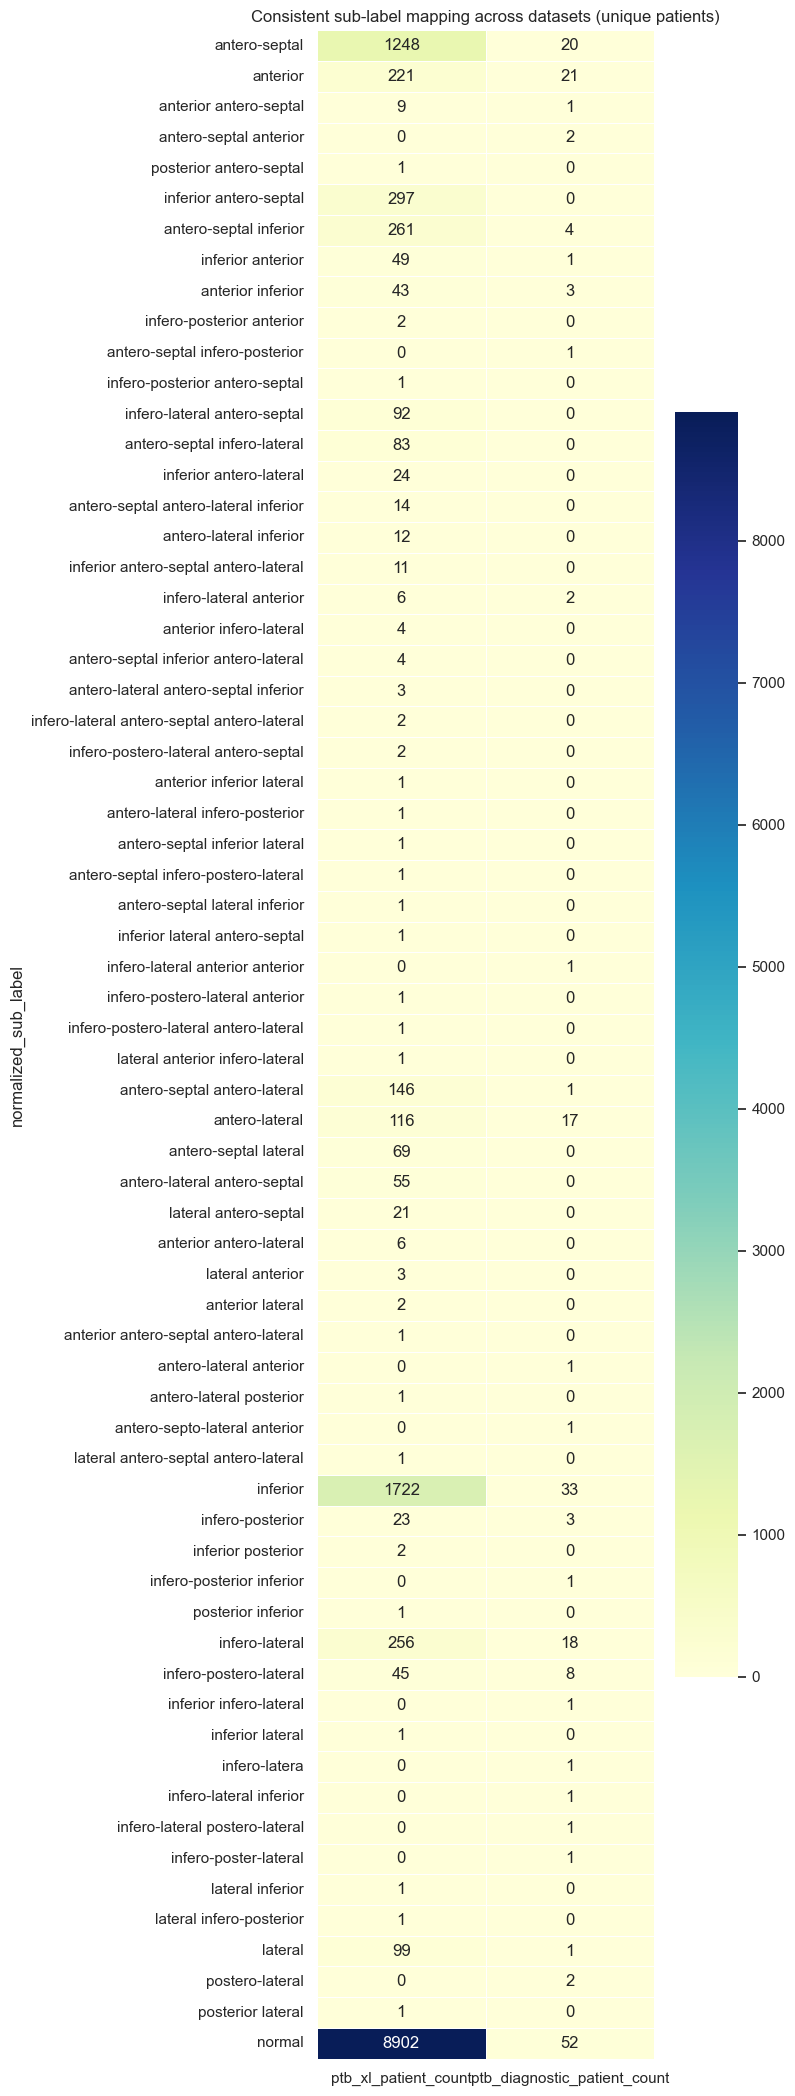

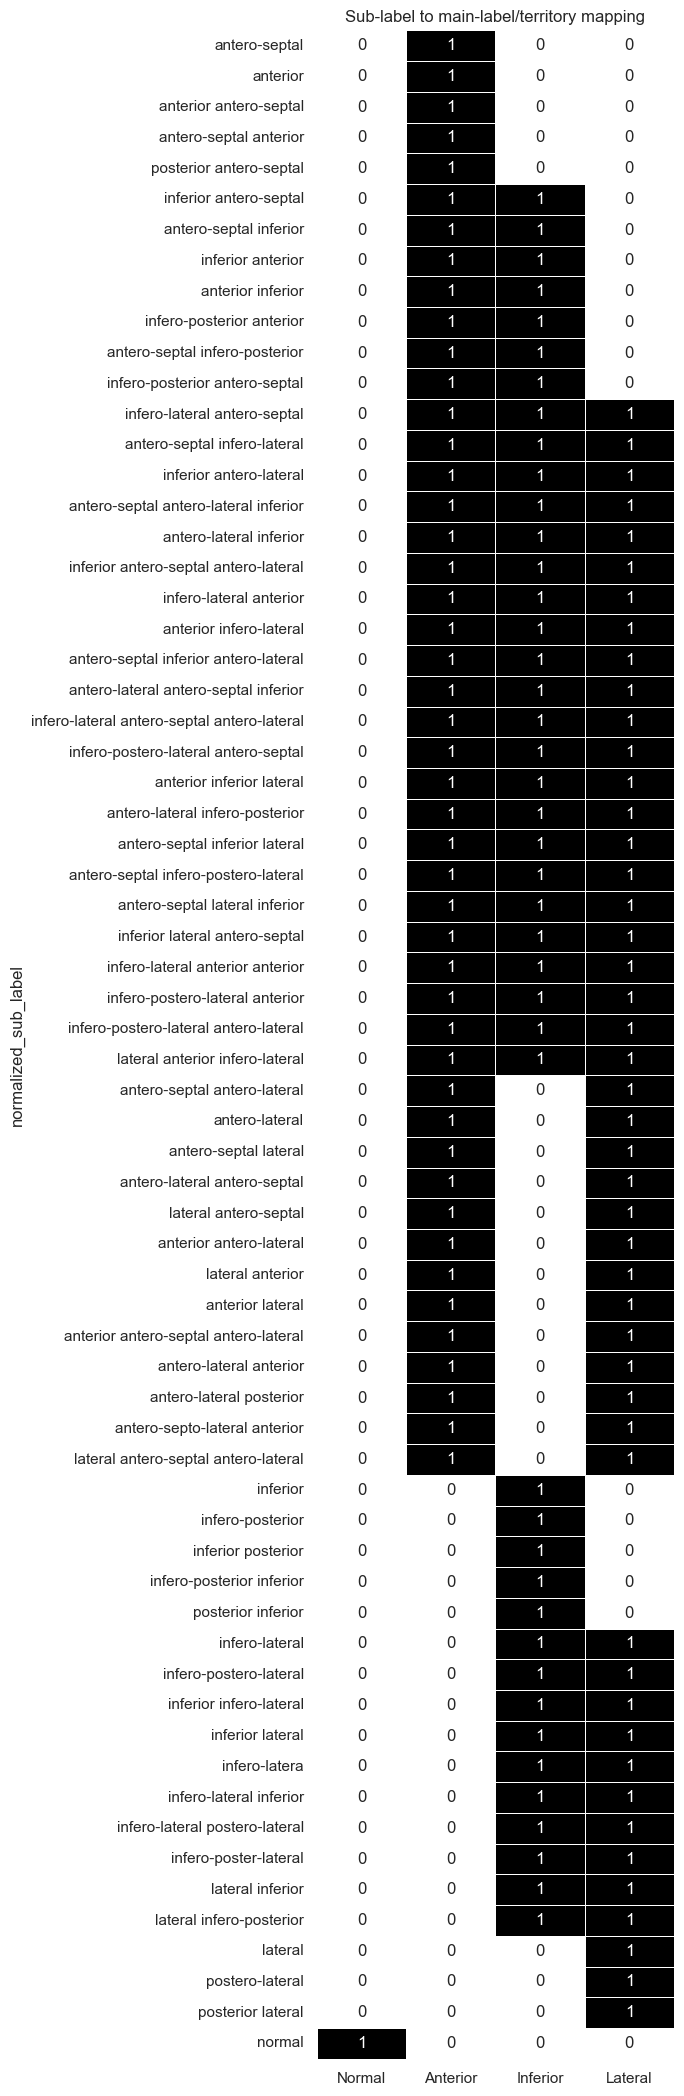

,normalized_sub_label,main_group,main_label_vector,territory_vector,ptb_xl_patient_count,ptb_diagnostic_patient_count
0,anterior,Anterior,"[0, 1, 0, 0]","[1, 0, 0]",221,21
1,anterior antero-septal,Anterior,"[0, 1, 0, 0]","[1, 0, 0]",9,1
2,antero-septal,Anterior,"[0, 1, 0, 0]","[1, 0, 0]",1248,20
3,antero-septal anterior,Anterior,"[0, 1, 0, 0]","[1, 0, 0]",0,2
4,posterior antero-septal,Anterior,"[0, 1, 0, 0]","[1, 0, 0]",1,0
...,...,...,...,...,...,...
61,lateral infero-posterior,Inferior+Lateral,"[0, 0, 1, 1]","[0, 1, 1]",1,0
62,lateral,Lateral,"[0, 0, 0, 1]","[0, 0, 1]",99,1
63,posterior lateral,Lateral,"[0, 0, 0, 1]","[0, 0, 1]",1,0
64,postero-lateral,Lateral,"[0, 0, 0, 1]","[0, 0, 1]",0,2


In [12]:
# Sub-label ring chart dengan legend dan mapping konsisten antar dataset.
def patient_sub_label_counts_for_mapping(dataset_name):
    labels = pd.read_csv(OUTPUT_ROOT / dataset_name / 'labels_all.csv')
    labels['patient_id'] = labels['patient_id'].astype(str)
    df = labels[['patient_id', 'sub_label']].drop_duplicates()
    counts = df.groupby('sub_label', as_index=False).agg(patient_count=('patient_id', 'nunique'))
    counts['normalized_sub_label'] = counts['sub_label'].map(normalize_label_text)
    counts['main_group'] = counts['normalized_sub_label'].map(sub_label_group)
    counts = counts.sort_values(['main_group', 'patient_count'], ascending=[True, False]).reset_index(drop=True)
    return counts

def plot_sub_label_ring_with_legend(counts, title, output_path, max_slices=22):
    plot_df = counts.sort_values('patient_count', ascending=False).copy()
    if len(plot_df) > max_slices:
        head = plot_df.iloc[:max_slices].copy()
        other_count = int(plot_df.iloc[max_slices:]['patient_count'].sum())
        other = pd.DataFrame([{'sub_label': 'Other', 'normalized_sub_label': 'other', 'main_group': 'Other', 'patient_count': other_count}])
        plot_df = pd.concat([head, other], ignore_index=True)
    plot_df = plot_df.sort_values(['main_group', 'patient_count'], ascending=[True, False]).reset_index(drop=True)
    total = int(plot_df['patient_count'].sum())
    colors = colors_for_sub_labels(plot_df['sub_label'].tolist())
    legend_labels = [f'{r.sub_label} - {int(r.patient_count)} ({r.patient_count / total:.1%})' for r in plot_df.itertuples()]

    fig, ax = plt.subplots(figsize=(10, 12))
    wedges, _ = ax.pie(
        plot_df['patient_count'],
        startangle=90,
        counterclock=False,
        colors=colors,
        labels=None,
        wedgeprops={'width': 0.38, 'edgecolor': 'white', 'linewidth': 1.8},
    )
    ax.text(0, 0, f'Unique\npatients\n{total}', ha='center', va='center', fontsize=14, fontweight='bold')
    ax.set_title(title, pad=18)
    ax.set_aspect('equal')
    ax.legend(wedges, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.04), ncol=1, frameon=False, fontsize=8, title='Sub-label')
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved:', output_path)

def build_consistent_sub_label_mapping(ptbxl_counts, ptbdiag_counts):
    all_sub = sorted(set(ptbxl_counts['normalized_sub_label']) | set(ptbdiag_counts['normalized_sub_label']))
    rows = []
    for sub in all_sub:
        territory = map_to_territory_vector(sub)
        group = sub_label_group(sub)
        main_vector = [1, 0, 0, 0] if sub == 'normal' and territory.sum() == 0 else [0, int(territory[0]), int(territory[1]), int(territory[2])]
        rows.append({
            'normalized_sub_label': sub,
            'main_group': group,
            'main_label_vector': json.dumps(main_vector),
            'territory_vector': json.dumps([int(x) for x in territory]),
            'ptb_xl_patient_count': int(ptbxl_counts.loc[ptbxl_counts.normalized_sub_label.eq(sub), 'patient_count'].sum()),
            'ptb_diagnostic_patient_count': int(ptbdiag_counts.loc[ptbdiag_counts.normalized_sub_label.eq(sub), 'patient_count'].sum()),
        })
    return pd.DataFrame(rows).sort_values(['main_group', 'normalized_sub_label']).reset_index(drop=True)

def plot_consistent_mapping_heatmaps(mapping):
    ordered = mapping.assign(total=mapping.ptb_xl_patient_count + mapping.ptb_diagnostic_patient_count).sort_values(['main_group', 'total'], ascending=[True, False])
    counts_mat = ordered.set_index('normalized_sub_label')[['ptb_xl_patient_count', 'ptb_diagnostic_patient_count']]
    fig, ax = plt.subplots(figsize=(8, max(6, 0.32 * len(counts_mat))))
    sns.heatmap(counts_mat, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, ax=ax)
    ax.set_title('Consistent sub-label mapping across datasets (unique patients)')
    fig.tight_layout()
    fig.savefig(FIG_ROOT / 'consistent_sub_label_mapping_counts_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    territory_mat = pd.DataFrame(
        [[1, 0, 0, 0] if row.main_group == 'Normal' else [0] + json.loads(row.territory_vector) for row in ordered.itertuples()],
        index=ordered['normalized_sub_label'],
        columns=MAIN_LABEL_COLUMNS,
    )
    fig, ax = plt.subplots(figsize=(7, max(6, 0.32 * len(territory_mat))))
    sns.heatmap(territory_mat, annot=True, fmt='d', cmap='Greys', cbar=False, linewidths=.5, ax=ax)
    ax.set_title('Sub-label to main-label/territory mapping')
    fig.tight_layout()
    fig.savefig(FIG_ROOT / 'consistent_sub_label_to_main_label_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

ptbxl_sub_counts_legend = patient_sub_label_counts_for_mapping('ptb_xl')
ptbdiag_sub_counts_legend = patient_sub_label_counts_for_mapping('ptb_diagnostic')
plot_sub_label_ring_with_legend(ptbxl_sub_counts_legend, 'PTB-XL: sub-label distribution by unique patient', FIG_ROOT / 'ptb_xl_patient_sub_label_ring_legend.png')
plot_sub_label_ring_with_legend(ptbdiag_sub_counts_legend, 'PTB Diagnostic: sub-label distribution by unique patient', FIG_ROOT / 'ptb_diagnostic_patient_sub_label_ring_legend.png')
consistent_sub_label_mapping = build_consistent_sub_label_mapping(ptbxl_sub_counts_legend, ptbdiag_sub_counts_legend)
consistent_sub_label_mapping.to_csv(FIG_ROOT / 'consistent_sub_label_mapping.csv', index=False)
plot_consistent_mapping_heatmaps(consistent_sub_label_mapping)
display(consistent_sub_label_mapping)

## Combined Audit

=== Combined PTB-XL + PTB Diagnostic label validation ===
Samples: 15446
Main label distribution:


,count
Normal,9607
Anterior,3274
Inferior,3473
Lateral,1332


Territory distribution:


,count
Anterior,3274
Inferior,3473
Lateral,1332


Multi-territory samples: 1942
First 10 mappings:


,record_id,dataset_source,raw_label,sub_label,main_label_vector,territory_vector,lead_prior_vector,fold
0,1,ptb_xl,NORM|LVOLT|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",3.0
1,2,ptb_xl,NORM|SBRAD,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",2.0
2,3,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",5.0
3,4,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",3.0
4,5,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",4.0
5,6,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",4.0
6,7,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",7.0
7,8,ptb_xl,IMI|ABQRS|SR,inferior,"[0, 0, 1, 0]","[0, 1, 0]","[0.0, 0.0, 0.33333334, 0.33333334, 0.33333334,...",9.0
8,9,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",10.0
9,10,ptb_xl,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",9.0


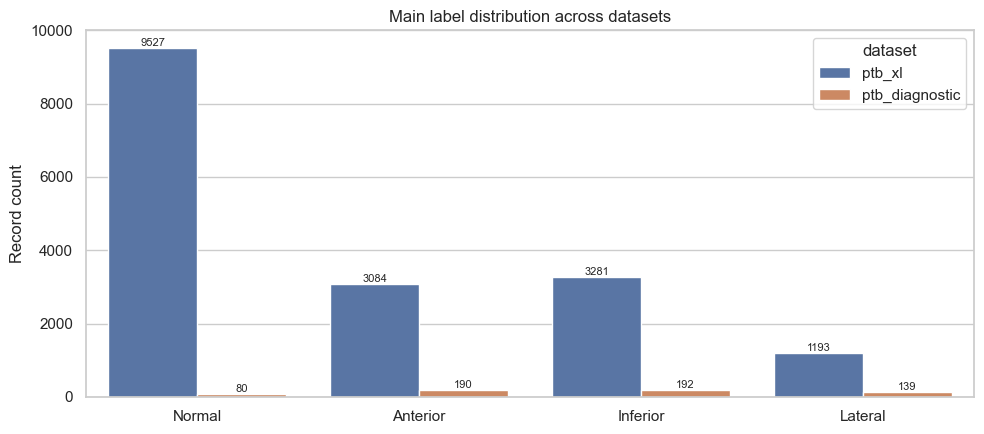

dataset,ptb_diagnostic,ptb_xl
label,,
Anterior,190,3084
Inferior,192,3281
Lateral,139,1193
Normal,80,9527


Combined labels saved to: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/dataset/combined_labels.csv
Figures saved to: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/figures/data_prep
Datasets saved to: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/dataset


In [13]:
# Gabungkan label dataframe agar langsung siap dipakai untuk training lintas dataset.
combined_label_df = pd.concat([ptbxl_labels_all, ptb_diag_labels_all], ignore_index=True)
combined_validation = validate_label_mapping(combined_label_df, 'Combined PTB-XL + PTB Diagnostic')
combined_label_df.to_csv(OUTPUT_ROOT / 'combined_labels.csv', index=False)

rows = []
for dataset_name, label_df in [('ptb_xl', ptbxl_labels_all), ('ptb_diagnostic', ptb_diag_labels_all)]:
    main = vector_matrix(label_df, 'main_label_vector', np.int8)
    for idx, label in enumerate(MAIN_LABEL_COLUMNS):
        rows.append({'dataset': dataset_name, 'label': label, 'count': int(main[:, idx].sum())})
combined_counts = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=combined_counts, x='label', y='count', hue='dataset', ax=ax)
ax.set_title('Main label distribution across datasets')
ax.set_xlabel('')
ax.set_ylabel('Record count')
for container in ax.containers:
    ax.bar_label(container, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_ROOT / 'combined_main_label_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

display(combined_counts.pivot(index='label', columns='dataset', values='count'))
print('Combined labels saved to:', OUTPUT_ROOT / 'combined_labels.csv')
print('Figures saved to:', FIG_ROOT)
print('Datasets saved to:', OUTPUT_ROOT)

## Patient Multi-Territory Audit

In [14]:
# Audit pasien multi-territory di dataset akhir.
def _parse_vector_column_for_audit(series, dtype=np.int8):
    return np.stack(series.apply(lambda x: np.array(json.loads(x), dtype=dtype)).to_numpy())

def audit_patient_multi_territory(dataset_name):
    label_path = OUTPUT_ROOT / dataset_name / 'labels_all.csv'
    labels = pd.read_csv(label_path)
    labels['patient_id'] = labels['patient_id'].astype(str)
    territory = _parse_vector_column_for_audit(labels['territory_vector'], np.int8)
    labels['territory_count'] = territory.sum(axis=1)
    labels['is_multi_territory_record'] = labels['territory_count'] > 1
    for idx, name in enumerate(TERRITORY_COLUMNS):
        labels[name] = territory[:, idx]

    patient_summary = labels.groupby('patient_id').agg(
        record_count=('record_id', 'count'),
        multi_territory_record_count=('is_multi_territory_record', 'sum'),
        sub_labels=('sub_label', lambda x: ' | '.join(sorted(set(map(str, x))))),
        record_ids=('record_id', lambda x: ' | '.join(map(str, x))),
        Anterior=('Anterior', 'max'),
        Inferior=('Inferior', 'max'),
        Lateral=('Lateral', 'max'),
    ).reset_index()
    patient_summary['patient_territory_count'] = patient_summary[TERRITORY_COLUMNS].sum(axis=1)
    patient_summary['is_multi_territory_patient'] = patient_summary['patient_territory_count'] > 1
    multi_patients = patient_summary[patient_summary['is_multi_territory_patient']].copy()

    print(f'=== {dataset_name}: patient multi-territory audit ===')
    print(f'Total patients                  : {patient_summary.patient_id.nunique()}')
    print(f'Multi-territory patients        : {len(multi_patients)}')
    print(f'Records with multi-territory    : {int(labels.is_multi_territory_record.sum())}')
    print('Patient territory combinations:')
    combo = multi_patients[TERRITORY_COLUMNS].astype(int).astype(str).agg(''.join, axis=1).value_counts().rename_axis('territory_binary_AIL').reset_index(name='patient_count')
    display(combo)

    detailed = multi_patients.sort_values(['patient_territory_count', 'multi_territory_record_count', 'record_count'], ascending=False)
    detail_path = FIG_ROOT / f'{dataset_name}_multi_territory_patient_audit.csv'
    detailed.to_csv(detail_path, index=False)
    print('Saved:', detail_path)
    display(detailed.head(20))
    return patient_summary, detailed

ptbxl_patient_audit, ptbxl_multi_territory_patients = audit_patient_multi_territory('ptb_xl')
ptbdiag_patient_audit, ptbdiag_multi_territory_patients = audit_patient_multi_territory('ptb_diagnostic')

=== ptb_xl: patient multi-territory audit ===
Total patients                  : 13443
Multi-territory patients        : 1537
Records with multi-territory    : 1790
Patient territory combinations:


,territory_binary_AIL,patient_count
0,110,606
1,101,385
2,011,275
3,111,271


Saved: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/figures/data_prep/ptb_xl_multi_territory_patient_audit.csv


,patient_id,record_count,multi_territory_record_count,sub_labels,record_ids,Anterior,Inferior,Lateral,patient_territory_count,is_multi_territory_patient
7455,20655.0,7,7,antero-lateral | antero-lateral+antero-septal ...,8163 | 9154 | 9168 | 9205 | 11566 | 13266 | 13290,1,1,1,3,True
4090,15825.0,6,6,inferior+antero-septal | infero-lateral,19759 | 19814 | 19842 | 19849 | 19864 | 19872,1,1,1,3,True
2205,13145.0,8,5,inferior | inferior+antero-septal | infero-lat...,21332 | 21338 | 21357 | 21365 | 21372 | 21497 ...,1,1,1,3,True
4954,17087.0,5,5,antero-lateral+inferior | antero-septal+infero...,15586 | 15594 | 15604 | 15621 | 15659,1,1,1,3,True
962,11369.0,4,4,inferior+antero-septal | infero-lateral+antero...,16327 | 16405 | 16449 | 16480,1,1,1,3,True
1809,12595.0,4,4,antero-lateral+antero-septal | antero-septal+i...,8618 | 8698 | 8753 | 8828,1,1,1,3,True
3670,15222.0,4,4,anterior+infero-lateral | infero-lateral | inf...,7282 | 7310 | 7333 | 7345,1,1,1,3,True
5454,17813.0,4,4,antero-septal+infero-lateral | infero-lateral+...,16275 | 16282 | 16423 | 16478,1,1,1,3,True
12117,8055.0,4,4,antero-septal+inferior+antero-lateral | inferi...,21037 | 21053 | 21056 | 21077,1,1,1,3,True
12386,8464.0,4,4,antero-septal+antero-lateral | antero-septal+i...,17037 | 17079 | 17103 | 17124,1,1,1,3,True


=== ptb_diagnostic: patient multi-territory audit ===
Total patients                  : 199
Multi-territory patients        : 63
Records with multi-territory    : 152
Patient territory combinations:


,territory_binary_AIL,patient_count
0,011,31
1,101,20
2,110,9
3,111,3


Saved: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/figures/data_prep/ptb_diagnostic_multi_territory_patient_audit.csv


,patient_id,record_count,multi_territory_record_count,sub_labels,record_ids,Anterior,Inferior,Lateral,patient_territory_count,is_multi_territory_patient
66,patient067,3,3,infero-lateral+anterior,s0227lre | s0230lre | s0283lre,1,1,1,3,True
84,patient086,1,1,infero-lateral+anterior anterior,s0316lre,1,1,1,3,True
182,patient268,1,1,infero-lateral+anterior,s0505_re,1,1,1,3,True
16,patient017,4,4,infero-lateral+inferior,s0053lre | s0055lre | s0063lre | s0075lre,0,1,1,2,True
40,patient041,4,4,infero-lateral+postero-lateral,s0132lre | s0136lre | s0138lre | s0276lre,0,1,1,2,True
44,patient045,4,4,infero-lateral,s0147lre | s0148lre | s0155lre | s0217lre,0,1,1,2,True
47,patient048,4,4,antero-lateral,s0171lre | s0172lre | s0180lre | s0277lre,1,0,1,2,True
53,patient054,4,4,infero-lateral,s0192lre | s0195lre | s0197lre | s0218lre,0,1,1,2,True
64,patient065,4,4,infero-postero-lateral,s0221lre | s0226lre | s0229lre | s0282lre,0,1,1,2,True
68,patient069,4,4,antero-lateral,s0232lre | s0233lre | s0234lre | s0284lre,1,0,1,2,True
